# Fase 1 · Etapa 2 — Selección de variables de la EPHC anual 2025

**Proyecto:** Brecha de la educación y su impacto en la movilidad laboral y salarios (Paraguay).
**Fuente:** Encuesta Permanente de Hogares Continua (EPHC) anual 2025, Instituto Nacional de Estadística (INE).
**Pregunta principal:** ¿De qué manera el nivel educativo impacta en los ingresos laborales de la Población Económicamente Activa (PEA) en Paraguay durante el año 2025?

**Objetivos específicos de referencia (propuesta):**
- **OE1** Describir el perfil educativo y laboral de la fuerza de trabajo.
- **OE2** Comparar los ingresos laborales según estrato educativo.
- **OE3** Examinar la calidad de la ocupación y la movilidad laboral (subocupación, precariedad, informalidad; IPS y RUC).
- **OE4** Identificar disparidades por sexo y área de residencia.

## Qué hace este notebook
Parte del **conjunto completo** (todas las columnas del archivo original), clasifica cada columna según el diccionario oficial como *conservar* o *descartar*, elimina las descartadas y guarda el conjunto reducido. Los criterios se aplican **por grupos de variables** y cada grupo queda vinculado a un objetivo específico, tal como exige la guía (Etapa 2, punto 6).

## Cómo ejecutarlo
1. Colocar el CSV original completo en la carpeta `data/`.
2. Ajustar `RUTA_ENTRADA` en la sección 1 si el archivo tiene otro nombre.
3. Ejecutar todo (*Kernel → Restart & Run All*).

Todas las rutas son relativas a la raíz del repositorio y no se edita ningún dato a mano.

## 1. Configuración

In [11]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 300)

# Rutas relativas a la raíz del repositorio (/data, /notebooks, /src, /output)
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_ENTRADA = RAIZ / "data" / "REG02_EPHC_ANUAL_2025.csv"      # nombre real del CSV completo
RUTA_SALIDA = RAIZ / "data" / "EPHC_2025_seleccion.csv"   # conjunto con las columnas conservadas
CARPETA_OUTPUT = RAIZ / "output"
CARPETA_OUTPUT.mkdir(parents=True, exist_ok=True)

# Identificador de persona (su unicidad se verifica en la sección 8)
CLAVE_PERSONA = ["UPM", "NVIVI", "NHOGA", "L02"]

## 2. Regla de selección por grupos

Dos diccionarios de Python son la **única fuente de verdad** de la selección:

- `CONSERVAR`: grupos de variables que se mantienen, con el objetivo específico al que sirven.
- `DESCARTAR`: grupos de variables que se eliminan, con el motivo y su vínculo con los objetivos.

**Criterios:** (1) relación directa con la pregunta y los objetivos, o necesidad de identificar, ponderar o controlar; (2) redundancia: si el INE ya consolidó la información en una variable derivada, se conserva solo esa; (3) unidad de análisis y alcance: ingreso laboral individual de personas ocupadas de 15 años o más.

Los nombres provienen del diccionario oficial `diccionario_EPHC_ANUAL_2025.xls` (213 variables distintas).

In [12]:
CONSERVAR = {
    "Identificación y diseño muestral": {
        "objetivo": "Transversal (OE1–OE4): clave única de persona y factor de expansión.",
        "justificacion": (
            "Clave primaria de la persona (UPM + NVIVI + NHOGA + L02), necesaria para "
            "verificar unicidad y detectar duplicados; el factor de expansión permite que"
            " las estimaciones representen a la población y no solo a la muestra."
        ),
        "variables": [
            "UPM", "NVIVI", "NHOGA", "L02", "Factor",
        ],
    },
    "Ubicación y variables sociodemográficas": {
        "objetivo": "OE1 y OE4 (sexo y área de residencia); controles de edad/experiencia.",
        "justificacion": (
            "Sexo, área urbana/rural, departamento y edad segmentan la brecha educativa "
            "(OE4) y permiten delimitar la población de 15 años o más (PET). P04 define "
            "si la persona es miembro del hogar (criterio de población de referencia) y "
            "P08A (año de nacimiento) se conserva como única variable con dimensión "
            "temporal disponible (posible análisis por cohorte)."
        ),
        "variables": [
            "DPTO", "AREA", "P02", "P04", "P06", "P08A",
        ],
    },
    "Educación": {
        "objetivo": "OE1, OE2 y OE4: variable explicativa principal.",
        "justificacion": (
            "Años de estudio, nivel y grado más alto aprobado, título obtenido y "
            "asistencia actual. Los dos últimos permiten distinguir nivel completo de "
            "incompleto y aislar a quienes aún estudian (nivel todavía no definitivo)."
        ),
        "variables": [
            "añoest", "ED0504", "ED06C", "ED08",
        ],
    },
    "Condición de actividad y perfil ocupacional": {
        "objetivo": "OE1 y OE3: define PEA/ocupados y su perfil.",
        "justificacion": (
            "Variables consolidadas por el INE: condición de actividad (ocupados, "
            "desocupados, inactivos, subocupación visible), categoría ocupacional, "
            "ocupación, rama, tamaño del establecimiento e informalidad."
        ),
        "variables": [
            "PEAA", "PEAD", "CATE_PEA", "OCUP_PEA", "RAMA_PEA", "TAMA_PEA", "Informalidad",
        ],
    },
    "Ingresos laborales": {
        "objetivo": "OE2: variable respuesta del proyecto.",
        "justificacion": (
            "Ingreso mensual de la ocupación principal, secundaria y otras ocupaciones, "
            "en su versión declarada (E01A–E01C) y en su versión «habitual» "
            "(e01aimde–e01cimde). Permite construir el ingreso principal y el ingreso "
            "laboral total; en la Etapa 3 se decidirá cuál versión se usa como principal."
        ),
        "variables": [
            "E01A", "E01B", "E01C", "e01aimde", "e01bimde", "e01cimde",
        ],
    },
    "Jornada laboral, pluriempleo y trayectoria": {
        "objetivo": "OE2 y OE3; experiencia para la regresión (Fases 2 y 3).",
        "justificacion": (
            "Horas trabajadas (ingreso por hora y subocupación), años en la ocupación y "
            "en el establecimiento (experiencia y movilidad laboral) y tenencia de otro "
            "trabajo (para el ingreso total)."
        ),
        "variables": [
            "HORAB", "HORABC", "HORABCO", "B06", "B07A", "B07M", "B07S", "B09A", "B09M",
            "B09S", "B31",
        ],
    },
    "Calidad del empleo y protección social": {
        "objetivo": "OE3: precariedad e informalidad (IPS, RUC).",
        "justificacion": (
            "Aporte a caja de jubilación y caja (IPS), seguro privado, vacaciones anuales"
            " pagadas, descanso semanal, sindicato, tipo de contrato, RUC, condición "
            "jurídica y factura legal del establecimiento, más tenencia de seguro médico "
            "(IPS u otro) como indicador de seguridad social."
        ),
        "variables": [
            "B10", "B11", "B12A", "B13", "B14", "B15", "B26", "B28", "B29", "B30", "S01A",
            "S01B", "S02",
        ],
    },
    "Subocupación y deseo de cambio de empleo": {
        "objetivo": "OE3: subocupación y movilidad laboral.",
        "justificacion": (
            "Disponibilidad para trabajar más horas, deseo de mejorar o cambiar de "
            "ocupación y búsqueda de otro trabajo estando empleado; permiten verificar la"
            " subocupación visible de PEAD y aproximar la movilidad laboral."
        ),
        "variables": [
            "D01", "D02", "D03", "D04",
        ],
    },
}

In [13]:
DESCARTAR = {
    "Parentesco, estado civil y documentación": {
        "vinculo": "Ningún objetivo específico las requiere.",
        "justificacion": (
            "Describen la composición familiar, la documentación civil y el día y mes de "
            "nacimiento. No forman parte de las variables definidas en la propuesta "
            "(educación, ingreso, ocupación, seguridad social, sexo, área y edad), y el "
            "día y mes de nacimiento son redundantes con la edad (P02)."
        ),
        "variables": [
            "P03", "P04A", "P04B", "P08D", "P08M", "P09",
        ],
    },
    "Referencias entre miembros del hogar": {
        "vinculo": "Ningún objetivo específico las requiere.",
        "justificacion": (
            "Son números de línea que solo sirven para vincular personas dentro de un "
            "mismo hogar. La unidad de análisis es la persona individual y no se planteó "
            "un análisis intrahogar."
        ),
        "variables": [
            "P05C", "P05P", "P05M", "B271", "B272",
        ],
    },
    "Idioma y alfabetización": {
        "vinculo": "OE1 y OE2 quedan cubiertos por añoest y ED0504.",
        "justificacion": (
            "El nivel de instrucción ya se mide con años de estudio y nivel alcanzado "
            "(categoría «Sin instrucción»), por lo que alfabetización y asistencia alguna"
            " vez son redundantes; el idioma del hogar queda fuera del alcance."
        ),
        "variables": [
            "ED01", "ED02", "ED03",
        ],
    },
    "Institución, abandono escolar y programas alimentarios escolares": {
        "vinculo": "Fuera del alcance de OE1–OE4.",
        "justificacion": (
            "Se refieren al sector de la institución actual, a las causas del abandono "
            "escolar y a la recepción de meriendas o almuerzos escolares. El proyecto "
            "estudia el efecto del nivel alcanzado sobre el ingreso, no las causas de no "
            "estudiar ni las políticas alimentarias."
        ),
        "variables": [
            "ED09", "ED10", "ED11F1", "ED11F1A", "ED11GH1", "ED11GH1A",
        ],
    },
    "Cuestionario de filtro de actividad y búsqueda de empleo": {
        "vinculo": "OE1 (cuantificar PEA y ocupados) queda cubierto por PEAA y PEAD.",
        "justificacion": (
            "Incluyen quién responde y las preguntas base con las que se clasifica a cada"
            " persona como ocupada, desocupada o inactiva. Esa clasificación ya viene "
            "construida en PEAA y PEAD, por lo que conservar ambas versiones sería "
            "redundante."
        ),
        "variables": [
            "A01", "A01A", "A02", "A03", "A04", "A04A", "A04B", "A05", "A07", "A08", "A10",
            "A11A", "A11M", "A11S",
        ],
    },
    "Historia laboral de personas desocupadas": {
        "vinculo": (
            "OE1 solo necesita contar a los desocupados (PEAA); OE2–OE4 trabajan con "
            "ocupados."
        ),
        "justificacion": (
            "Refieren a la última ocupación, al tiempo sin trabajo y a la razón de haber "
            "dejado el empleo, es decir, a personas sin ocupación en el período de "
            "referencia, que quedan fuera de la unidad de análisis (ocupados). Las "
            "características de la última ocupación ya están en las variables *_PEA."
        ),
        "variables": [
            "A12", "A13REC", "A14REC", "A15", "A16", "A17A", "A17M", "A17S", "A18",
        ],
    },
    "Variables duplicadas de la ocupación principal": {
        "vinculo": "OE1 y OE3 quedan cubiertos por las variables *_PEA.",
        "justificacion": (
            "Comparten la misma codificación que OCUP_PEA, RAMA_PEA, TAMA_PEA y CATE_PEA,"
            " que el INE consolida para ocupados y desocupados. Se conserva una sola "
            "versión para evitar columnas repetidas; el notebook verifica empíricamente "
            "la coincidencia antes de eliminarlas."
        ),
        "variables": [
            "B01REC", "B02REC", "B08", "B12",
        ],
    },
    "Detalle diario de horas y razones de la jornada": {
        "vinculo": "OE2 y OE3 quedan cubiertos por las horas semanales.",
        "justificacion": (
            "Son horas por día de la semana y razones por las que no se trabajó la "
            "jornada habitual. Las horas semanales ya están resumidas en HORAB, HORABC, "
            "HORABCO y B06, suficientes para ajustar el ingreso por jornada y definir "
            "subocupación."
        ),
        "variables": [
            "B03LU", "B03MA", "B03MI", "B03JU", "B03VI", "B03SA", "B03DO", "B04", "B05",
        ],
    },
    "Detalle de pagos y beneficios en especie del trabajo principal": {
        "vinculo": "OE2 queda cubierto por los ingresos consolidados.",
        "justificacion": (
            "Descomponen el pago del trabajo principal (unidad de tiempo, días, "
            "adicionales, aguinaldo, comidas, vivienda, uniforme y costo del seguro "
            "privado). El ingreso ya está consolidado en E01A y e01aimde; mantener los "
            "componentes agregaría muchas columnas dispersas sin aportar a la comparación"
            " por nivel educativo."
        ),
        "variables": [
            "B12B", "B12C", "B16G", "B16U", "B16D", "B16T", "B17", "B18AG", "B18AU",
            "B18BG", "B18BU", "B19", "B20G", "B20U", "B20D", "B20T", "B21", "B22", "B23",
            "B24", "B25",
        ],
    },
    "Ocupación secundaria y otras ocupaciones (detalle)": {
        "vinculo": "OE2 queda cubierto por E01B, E01C y las horas totales.",
        "justificacion": (
            "Detallan ocupación, rama, horas, aportes, contrato, RUC y pagos de los "
            "trabajos secundarios y otros. Lo necesario para el ingreso laboral total "
            "(E01B, E01C), las horas totales (HORABC, HORABCO) y la existencia de otro "
            "trabajo (B31) ya se conserva en forma resumida."
        ),
        "variables": [
            "C01REC", "C02REC", "C03", "C04", "C05", "C06", "C07", "C08", "C09", "C101",
            "C102", "C11G", "C11U", "C11D", "C11T", "C12", "C13AG", "C13AU", "C13BG",
            "C13BU", "C14", "C14A", "C14B", "C14C", "C15", "C16REC", "C17REC", "C18",
            "C18A", "C18B", "C19",
        ],
    },
    "Ingresos no laborales": {
        "vinculo": "OE2 se acota a ingresos laborales.",
        "justificacion": (
            "Corresponden a alquileres, intereses, ayuda familiar, jubilaciones, "
            "pensiones, transferencias del Estado (Tekoporã, Adulto Mayor), víveres y "
            "otros ingresos. La pregunta se limita al ingreso laboral, por lo que el "
            "«ingreso total» se define como la suma de los ingresos de las ocupaciones "
            "(principal, secundaria y otras)."
        ),
        "variables": [
            "E01D", "E01E", "E01F", "E01G", "E01H", "E01I", "E01J", "E01K", "E01L", "E01M",
            "e01dde", "e01ede", "e01fde", "e01gde", "e01hde", "e01ide", "e01jde", "e01kde",
            "e01lde", "e01mde", "e01kjde", "e02bde", "ingrevasode", "ingrealmuerzode",
        ],
    },
    "Pobreza e ingreso per cápita del hogar": {
        "vinculo": "Fuera del alcance de OE1–OE4 (unidad de análisis: persona).",
        "justificacion": (
            "Son medidas calculadas a nivel de hogar (ingreso per cápita, condición de "
            "pobreza, quintiles y deciles). Miden el bienestar del hogar y no la "
            "remuneración individual que la pregunta busca explicar."
        ),
        "variables": [
            "ipcm", "pobrezai", "pobnopoi", "quintili", "decili", "quintiai", "decilai",
        ],
    },
    "Características del hogar y educación de otros miembros": {
        "vinculo": "Ningún objetivo específico las requiere.",
        "justificacion": (
            "Describen el tipo de hogar y el nivel de instrucción del jefe, cónyuge, "
            "padre y madre. La pregunta se centra en la educación de la propia persona "
            "ocupada."
        ),
        "variables": [
            "TIPOHOGA", "NJEF", "NCON", "NPAD", "NMAD",
        ],
    },
    "Razones de inactividad y de deseo de cambio": {
        "vinculo": "OE3 queda cubierto por D01–D04.",
        "justificacion": (
            "La razón de inactividad corresponde a personas fuera de la PEA; la razón "
            "para desear cambiar de empleo es un detalle motivacional que excede lo "
            "necesario para medir subocupación y movilidad (D01–D04)."
        ),
        "variables": [
            "ra06ya09", "D05",
        ],
    },
    "Salud: morbilidad y uso de servicios": {
        "vinculo": "Fuera del alcance de OE1–OE4.",
        "justificacion": (
            "Enfermedades, consultas, internaciones y medicamentos de los últimos 90 "
            "días. No se relacionan con el ingreso laboral ni con la calidad del empleo; "
            "solo se conservan las variables de tenencia de seguro (S01A, S01B, S02) como"
            " indicador de seguridad social."
        ),
        "variables": [
            "S03", "S03A", "S03B", "S03C", "S04", "S05", "S06", "S07", "S08", "S09",
        ],
    },
    "Variable constante": {
        "vinculo": "Ninguno.",
        "justificacion": (
            "Toma un único valor (2025) en todos los registros, por lo que no aporta "
            "variabilidad; el año queda documentado en el nombre del archivo y en el "
            "informe."
        ),
        "variables": [
            "AÑO",
        ],
    },
}

## 3. Tabla de decisión y control de cobertura

Se construye una tabla con una fila por variable y se comprueba que ninguna variable aparezca en dos grupos. Los nombres se comparan sin tildes, sin distinguir mayúsculas y sin sufijos de duplicado (`.1`, `_x`, `_y`), para tolerar diferencias de formato entre el diccionario y el CSV.

In [14]:
def clave(nombre):
    """Normaliza un nombre de columna: sin tildes, en minúsculas y sin sufijos de duplicado."""
    s = unicodedata.normalize("NFKD", str(nombre).strip())
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"(\.\d+|_x|_y)$", "", s, flags=re.IGNORECASE)
    return s.casefold()


filas = []
for grupo, d in CONSERVAR.items():
    filas += [{"variable": v, "decision": "conservar", "grupo": grupo,
               "objetivo_vinculado": d["objetivo"], "justificacion": d["justificacion"]}
              for v in d["variables"]]
for grupo, d in DESCARTAR.items():
    filas += [{"variable": v, "decision": "descartar", "grupo": grupo,
               "objetivo_vinculado": d["vinculo"], "justificacion": d["justificacion"]}
              for v in d["variables"]]

decision = pd.DataFrame(filas)
decision["clave"] = decision["variable"].map(clave)

assert decision["clave"].is_unique, "Hay variables repetidas entre los grupos"
print(f"Variables clasificadas: {len(decision)} "
      f"(conservar: {(decision.decision == 'conservar').sum()}, "
      f"descartar: {(decision.decision == 'descartar').sum()})")

resumen_grupos = (decision.groupby(["decision", "grupo"], sort=False)
                  .size().rename("n_variables").reset_index())
resumen_grupos

Variables clasificadas: 213 (conservar: 56, descartar: 157)


,decision,grupo,n_variables
0,conservar,Identificación y diseño muestral,5
1,conservar,Ubicación y variables sociodemográficas,6
2,conservar,Educación,4
3,conservar,Condición de actividad y perfil ocupacional,7
4,conservar,Ingresos laborales,6
5,conservar,"Jornada laboral, pluriempleo y trayectoria",11
6,conservar,Calidad del empleo y protección social,13
7,conservar,Subocupación y deseo de cambio de empleo,4
8,descartar,"Parentesco, estado civil y documentación",6
9,descartar,Referencias entre miembros del hogar,5


## 4. Carga del conjunto completo

Se lee el CSV original tal como viene (sin modificar), probando las codificaciones y separadores habituales.

In [15]:
def leer_base(ruta):
    """Lee el CSV probando codificaciones y separadores habituales."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Coloque el CSV original en /data y ajuste RUTA_ENTRADA.")
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        for sep in (",", ";", "\t", "|"):
            try:
                muestra = pd.read_csv(ruta, sep=sep, encoding=enc, nrows=5)
                if muestra.shape[1] < 20:      # separador incorrecto
                    continue
                return pd.read_csv(ruta, sep=sep, encoding=enc, low_memory=False), enc, sep
            except (UnicodeDecodeError, pd.errors.ParserError):
                continue
    raise ValueError("No se pudo leer el archivo: revise el separador y la codificación.")


df, codificacion, separador = leer_base(RUTA_ENTRADA)
print(f"Archivo: {RUTA_ENTRADA.name} | codificación: {codificacion} | separador: {separador!r}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Archivo: REG02_EPHC_ANUAL_2025.csv | codificación: utf-8 | separador: ';'
Filas: 55,934 | Columnas: 213
Memoria: 536.8 MB


## 5. Auditoría: ¿la base coincide con el diccionario?

Cada columna real del archivo recibe un estado:

- `conservar` / `descartar`: está clasificada en los grupos de la sección 2.
- `copia duplicada`: repite una columna ya vista (por ejemplo `L02` o `Factor`, que aparecen en las tres tablas del diccionario).
- `sin clasificar`: existe en el archivo pero no en el diccionario. **Se conserva de forma provisoria** para no perder información sin revisarla; hay que decidir qué hacer con ella.

In [16]:
por_clave = decision.set_index("clave")
vistos = {}          # clave normalizada -> nombre real de la primera columna que la usa
registro = []
for col in df.columns:
    k = clave(col)
    if str(col).startswith("Unnamed"):
        estado, grupo = "descartar", "Índice residual del archivo"
    elif k not in por_clave.index:
        estado, grupo = "sin clasificar", "—"
    elif k in vistos:
        estado, grupo = "copia duplicada", por_clave.loc[k, "grupo"]
    else:
        estado, grupo = por_clave.loc[k, "decision"], por_clave.loc[k, "grupo"]
    vistos.setdefault(k, col)
    registro.append({"columna": col, "clave": k, "estado": estado, "grupo": grupo})
registro = pd.DataFrame(registro)

print("Estado de las columnas del archivo:")
print(registro["estado"].value_counts().to_string())

ausentes = decision.loc[~decision["clave"].isin(registro["clave"]), "variable"].tolist()
print(f"\nVariables del diccionario que NO están en el archivo: {ausentes if ausentes else 'ninguna'}")

sin_clasificar = registro.loc[registro["estado"] == "sin clasificar", "columna"].tolist()
print(f"Columnas del archivo que NO están en el diccionario: {sin_clasificar if sin_clasificar else 'ninguna'}")

copias = registro.loc[registro["estado"] == "copia duplicada", "columna"].tolist()
for col in copias:
    original = vistos[clave(col)]
    igual = df[col].equals(df[original])
    print(f"Copia duplicada {col!r} vs {original!r}: {'idénticas' if igual else 'DISTINTAS, revisar'}")

Estado de las columnas del archivo:
estado
descartar    157
conservar     56

Variables del diccionario que NO están en el archivo: ninguna
Columnas del archivo que NO están en el diccionario: ninguna


## 6. Verificación de redundancias antes de eliminar

Las variables `B01REC`, `B02REC`, `B08` y `B12` se descartan por repetir la codificación de `OCUP_PEA`, `RAMA_PEA`, `TAMA_PEA` y `CATE_PEA`. Antes de eliminarlas se comprueba con los datos, entre las personas ocupadas (`PEAA == 1`), qué porcentaje de registros coincide. Si la coincidencia es menor al 100 %, conviene revisar la diferencia antes de descartar.

In [17]:
def col_real(nombre):
    """Nombre real de la columna en el archivo (o None si no existe)."""
    return vistos.get(clave(nombre))


def coincidencia(a, b, mascara):
    ca, cb = col_real(a), col_real(b)
    if ca is None or cb is None:
        return None
    x = pd.to_numeric(df.loc[mascara, ca], errors="coerce")
    y = pd.to_numeric(df.loc[mascara, cb], errors="coerce")
    valido = x.notna() & y.notna()
    return int(valido.sum()), float((x[valido] == y[valido]).mean())


c_peaa = col_real("PEAA")
ocupados = (pd.to_numeric(df[c_peaa], errors="coerce").eq(1)
            if c_peaa else pd.Series(True, index=df.index))

resultado = []
for descartada, conservada in [("B01REC", "OCUP_PEA"), ("B02REC", "RAMA_PEA"),
                               ("B08", "TAMA_PEA"), ("B12", "CATE_PEA")]:
    r = coincidencia(descartada, conservada, ocupados)
    resultado.append({"descartada": descartada, "conservada": conservada,
                      "n_comparados": None if r is None else r[0],
                      "coincidencia_%": None if r is None else round(100 * r[1], 2)})
pd.DataFrame(resultado)

,descartada,conservada,n_comparados,coincidencia_%
0,B01REC,OCUP_PEA,29008,100.00
1,B02REC,RAMA_PEA,29008,100.00
2,B08,TAMA_PEA,29008,100.00
3,B12,CATE_PEA,29008,99.43


## 7. Eliminación de las columnas descartadas

Se eliminan del DataFrame completo todas las columnas con estado `descartar` o `copia duplicada`. Las `sin clasificar` se mantienen hasta decidir qué hacer con ellas.

In [18]:
a_eliminar = registro.loc[registro["estado"].isin(["descartar", "copia duplicada"]), "columna"].tolist()
df_sel = df.drop(columns=a_eliminar)

print(f"Columnas antes: {df.shape[1]} | eliminadas: {len(a_eliminar)} | después: {df_sel.shape[1]}")
print(f"Reducción: {100 * len(a_eliminar) / df.shape[1]:.1f} % de las columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB -> "
      f"{df_sel.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Filas (sin cambios): {df_sel.shape[0]:,}")

conservadas_por_grupo = (registro[registro["estado"] == "conservar"]
                         .groupby("grupo", sort=False)["columna"].apply(list))
for grupo, cols in conservadas_por_grupo.items():
    print(f"\n{grupo} ({len(cols)}): {', '.join(cols)}")

Columnas antes: 213 | eliminadas: 157 | después: 56
Reducción: 73.7 % de las columnas
Memoria: 536.8 MB -> 129.1 MB
Filas (sin cambios): 55,934

Identificación y diseño muestral (5): UPM, NVIVI, NHOGA, L02, FACTOR

Ubicación y variables sociodemográficas (6): DPTO, AREA, P02, P04, P06, P08A

Jornada laboral, pluriempleo y trayectoria (11): B06, B07A, B07M, B07S, B09A, B09M, B09S, B31, HORAB, HORABC, HORABCO

Calidad del empleo y protección social (13): B10, B11, B12A, B13, B14, B15, B26, B28, B29, B30, S01A, S01B, S02

Subocupación y deseo de cambio de empleo (4): D01, D02, D03, D04

Ingresos laborales (6): E01A, E01B, E01C, e01aimde, e01bimde, e01cimde

Educación (4): ED0504, ED06C, ED08, añoest

Condición de actividad y perfil ocupacional (7): CATE_PEA, TAMA_PEA, OCUP_PEA, RAMA_PEA, PEAD, PEAA, informalidad


## 8. Verificaciones del conjunto reducido

Se comprueba que las variables clave sigan presentes, que la clave de persona sea única (Etapa 2, punto 3) y cómo quedan los faltantes de las columnas conservadas (control informativo, no se imputa nada aquí).

In [19]:
claves_reales = [col_real(c) for c in CLAVE_PERSONA]
faltan_claves = [c for c, r in zip(CLAVE_PERSONA, claves_reales) if r is None]

if faltan_claves:
    print(f"ATENCIÓN: faltan columnas de la clave de persona: {faltan_claves}")
else:
    duplicados = int(df_sel.duplicated(subset=claves_reales).sum())
    print(f"Registros duplicados según {CLAVE_PERSONA}: {duplicados}")
    print("Clave verificada: cada fila es una persona única."
          if duplicados == 0 else "ATENCIÓN: la clave no es única, revisar antes de continuar.")

clave_variables = ["añoest", "ED0504", "E01A", "e01aimde", "PEAA", "P02", "P06", "AREA", "Factor"]
for v in clave_variables:
    if col_real(v) is None or col_real(v) not in df_sel.columns:
        print(f"ATENCIÓN: la variable {v} no está en el conjunto reducido")

faltantes = (df_sel.isna().mean().mul(100).round(1)
             .sort_values(ascending=False).rename("% faltante").head(15))
print("\nColumnas con más valores en blanco (top 15):")
print(faltantes.to_string())

Registros duplicados según ['UPM', 'NVIVI', 'NHOGA', 'L02']: 0
Clave verificada: cada fila es una persona única.

Columnas con más valores en blanco (top 15):
UPM      0.0
NVIVI    0.0
NHOGA    0.0
DPTO     0.0
AREA     0.0
L02      0.0
P02      0.0
P04      0.0
P06      0.0
P08A     0.0
B06      0.0
B07A     0.0
B07M     0.0
B07S     0.0
B09A     0.0


## 9. Guardado

Se guarda el conjunto reducido y dos registros de trazabilidad en `output/`: uno con el estado de cada columna del archivo y otro con la decisión y su justificación por variable. Esos archivos alimentan el informe de justificación.

In [20]:
RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)
df_sel.to_csv(RUTA_SALIDA, index=False, encoding="utf-8")
registro.drop(columns="clave").to_csv(CARPETA_OUTPUT / "registro_columnas_base.csv",
                                      index=False, encoding="utf-8")
decision.drop(columns="clave").to_csv(CARPETA_OUTPUT / "decision_variables_por_grupo.csv",
                                      index=False, encoding="utf-8")

print("Archivos generados:")
for ruta in (RUTA_SALIDA, CARPETA_OUTPUT / "registro_columnas_base.csv",
             CARPETA_OUTPUT / "decision_variables_por_grupo.csv"):
    print(f" - {ruta.relative_to(RAIZ)}")

Archivos generados:
 - data/EPHC_2025_seleccion.csv
 - output/registro_columnas_base.csv
 - output/decision_variables_por_grupo.csv


## 10. Cierre

El conjunto reducido conserva las columnas necesarias para responder la pregunta principal y para las fases inferencial y predictiva; el resto se descartó por grupos, con la justificación registrada en la sección 2 y en `output/decision_variables_por_grupo.csv`.

**Siguientes pasos (Etapa 3, limpieza y transformación):**
- Definir la población de análisis (personas de 15 años o más y ocupadas, `PEAA == 1`) y documentar cuántos registros se excluyen.
- Tratar los códigos de no respuesta que el diccionario define como valores especiales (por ejemplo 99, 999, 9999 y 99999999999 según la variable), que no deben entrar como cantidades reales.
- Decidir qué versión del ingreso se usa como principal (declarada o habitual) y construir el ingreso laboral total.
- Recodificar el nivel educativo en estratos (básica, media, terciaria/universitaria) con puntos de corte justificados.

# Etapa 3 — Limpieza y transformación

Esta sección parte exclusivamente de `df_sel`, generado a partir del archivo CSV original en las etapas anteriores. Todas las reglas quedan expresadas en código y generan una **bitácora reproducible**.

**Unidad de análisis:** persona de 15 años o más, ocupada (`PEAA == 1`), de acuerdo con la definición adoptada en la Etapa 2.

**Criterios generales:**
- Los códigos de no respuesta definidos por el diccionario se convierten a `NaN`; no se interpretan como cantidades.
- Los valores fuera de dominio se convierten a `NaN` únicamente cuando el diccionario permite establecer que son imposibles.
- No se eliminan observaciones por atípicos estadísticos solo por ser extremos: un ingreso alto puede ser real. Los atípicos se diagnostican y se conservan salvo imposibilidad o error de codificación.
- La imputación no se realiza de forma automática sobre variables sustantivas: para una encuesta de ingresos, inventar valores puede introducir sesgo. Los faltantes se conservan explícitamente como `NaN` y se documentan.


## 11. Población de análisis y funciones de trazabilidad

In [21]:
# Trabajamos sobre una copia: el CSV original y df_sel no se modifican.
df3 = df_sel.copy()

bitacora = []

def registrar(etapa, variable, accion, n_afectados, fundamento, detalle=""):
    bitacora.append({
        "etapa": etapa,
        "variable": variable,
        "accion": accion,
        "n_afectados": int(n_afectados),
        "fundamento": fundamento,
        "detalle": detalle
    })

def real(v):
    """Devuelve el nombre real de una variable, tolerando diferencias de mayúsculas."""
    k = clave(v)
    candidatos = [c for c in df3.columns if clave(c) == k]
    return candidatos[0] if candidatos else None

def serie(v):
    c = real(v)
    return df3[c] if c else None

# Población: personas de 15 años o más y ocupadas.
edad = pd.to_numeric(serie("P02"), errors="coerce")
peaa = pd.to_numeric(serie("PEAA"), errors="coerce")

m_edad = edad.ge(15)
m_ocup = peaa.eq(1)
m_poblacion = m_edad & m_ocup

n0 = len(df3)
n_no_edad = int((~m_edad).sum())
n_no_ocup = int((m_edad & ~m_ocup).sum())
n_final_poblacion = int(m_poblacion.sum())

registrar("Población", "P02/PEAA", "Excluir menores de 15 años", n_no_edad,
          "La unidad de análisis definida en la Etapa 2 es la población de 15 años o más ocupada.",
          "Se aplica P02 >= 15.")
registrar("Población", "PEAA", "Excluir no ocupados", n_no_ocup,
          "La pregunta del proyecto se refiere a ingresos laborales de personas ocupadas.",
          "Se aplica PEAA == 1.")

print(f"Filas iniciales del conjunto seleccionado: {n0:,}")
print(f"Personas de 15+ ocupadas: {n_final_poblacion:,}")
print(f"Excluidas por edad: {n_no_edad:,}")
print(f"Excluidas por condición de actividad dentro de 15+: {n_no_ocup:,}")

df3 = df3.loc[m_poblacion].copy()


Filas iniciales del conjunto seleccionado: 55,934
Personas de 15+ ocupadas: 28,735
Excluidas por edad: 13,901
Excluidas por condición de actividad dentro de 15+: 13,298


## 12. Valores faltantes: cuantificación, mecanismo y estrategia

Se cuantifican `NaN` antes y después de recodificar los códigos especiales. El diccionario distingue `NR` (no respuesta) y `Blanco`; ambos representan ausencia de información, pero se conserva su trazabilidad mediante una tabla previa.

**Mecanismo de ausencia:** con una sola sección transversal no puede demostrarse que los faltantes sean MCAR, MAR o MNAR. Por ello, el notebook no impone uno de esos mecanismos. Se reportan tasas de ausencia por variable y se conservan los faltantes sin imputación cuando la variable es sustantiva. Las variables que no aplican por diseño quedan como faltantes estructurales y no se imputan.


In [22]:
# Códigos especiales documentados en el diccionario para las variables seleccionadas.
# La lista se aplica solo a variables donde el diccionario identifica esos códigos
# como NR/no respuesta. No se convierte un "6" genéricamente en faltante porque en
# varias variables "6" significa "No".
CODIGOS_NR = {
    "añoest": [99],
    "P08A": [9999],
    "PEAA": [9],
    "PEAD": [9],
    "E01A": [99999999999],
    "E01B": [99999999999],
    "E01C": [99999999999],
    "e01aimde": [99999999999],
    "e01bimde": [99999999999],
    "e01cimde": [99999999999],
    "HORAB": [999],
    "HORABC": [999],
    "HORABCO": [999],
    "B06": [999],
    "B07A": [99],
    "B07M": [99],
    "B07S": [99],
    "B09A": [99],
    "B09M": [99],
    "B09S": [99],
    "D02": [999],
    "B13": [99],
    "B14": [99],
    "B10": [9],
    "B11": [9],
    "B12A": [9],
    "B15": [9],
    "B26": [9],
    "B28": [9],
    "B29": [9],
    "B30": [9],
    "B31": [9],
    "D01": [9],
    "D03": [9],
    "D04": [9],
    "S02": [9],
}

faltantes_pre = []
for v, codigos in CODIGOS_NR.items():
    c = real(v)
    if c is None:
        continue
    s = df3[c]
    # Se registra cada código antes de convertirlo a NaN.
    for codigo in codigos:
        m = pd.to_numeric(s, errors="coerce").eq(codigo)
        n = int(m.sum())
        if n:
            faltantes_pre.append({
                "variable": c, "codigo_especial": codigo, "n": n
            })
            s2 = s.copy()
            s2.loc[m] = np.nan
            df3[c] = s2
            registrar("Faltantes", c, f"Recodificar código {codigo} como NaN", n,
                      "El diccionario define el código como NR/no respuesta.",
                      "No se imputa; se conserva como ausencia explícita.")

# Blancos ya leídos como NaN por pandas; se cuantifican.
tabla_faltantes = (df3.isna().sum()
                   .to_frame("n_faltantes")
                   .assign(porcentaje=lambda x: 100*x["n_faltantes"]/len(df3))
                   .sort_values("porcentaje", ascending=False))

print("Top 20 de faltantes después de recodificar códigos especiales:")
display(tabla_faltantes.head(20).round(2))

if faltantes_pre:
    display(pd.DataFrame(faltantes_pre).sort_values(["variable", "codigo_especial"]))


Top 20 de faltantes después de recodificar códigos especiales:


,n_faltantes,porcentaje
E01A,438,1.52
E01B,46,0.16
añoest,14,0.05
D01,14,0.05
D03,12,0.04
D04,12,0.04
B07M,9,0.03
B26,9,0.03
B07A,9,0.03
B12A,8,0.03


,variable,codigo_especial,n
7,B07A,99,9
8,B07M,99,9
9,B09A,99,7
10,B09M,99,7
13,B10,9,7
14,B11,9,8
15,B12A,9,8
11,B13,99,5
12,B14,99,2
16,B15,9,5


## 13. Duplicados exactos y parciales

La clave de persona definida en la Etapa 2 es `UPM + NVIVI + NHOGA + L02`.

1. Se eliminan duplicados **exactos** de filas, porque no contienen información adicional.
2. Después se revisan duplicados **parciales** por clave de persona.
3. Si varias filas de una misma persona son idénticas en todas las variables sustantivas, se conserva una sola.
4. Si existen conflictos reales entre filas de la misma clave, el pipeline no inventa una reconciliación: genera una auditoría y detiene la ejecución para revisión, porque seleccionar arbitrariamente una fila sería una transformación no justificada.


In [23]:
# 1) Duplicados exactos
n_dup_exact = int(df3.duplicated(keep=False).sum())
n_dup_exact_elim = int(df3.duplicated(keep="first").sum())
if n_dup_exact_elim:
    df3 = df3.drop_duplicates(keep="first").copy()
registrar("Duplicados", "todas", "Eliminar duplicados exactos", n_dup_exact_elim,
          "Dos filas completamente idénticas no aportan información adicional.",
          f"Filas involucradas antes de eliminar: {n_dup_exact:,}.")

# 2) Duplicados por clave de persona
key_cols = [real(v) for v in CLAVE_PERSONA]
if any(c is None for c in key_cols):
    raise KeyError(f"No se pudo reconstruir la clave de persona: {CLAVE_PERSONA}")

dup_key = df3.duplicated(subset=key_cols, keep=False)
n_dup_key = int(dup_key.sum())

if n_dup_key:
    # Comparamos cada grupo con su primera fila en todas las columnas.
    non_key = [c for c in df3.columns if c not in key_cols]
    grupos_conflictivos = []
    grupos_identicos = 0

    for _, g in df3.loc[dup_key].groupby(key_cols, dropna=False, sort=False):
        # Un grupo es redundante si todas sus filas coinciden en cada variable no clave.
        if len(g[non_key].drop_duplicates()) == 1:
            grupos_identicos += 1
        else:
            grupos_conflictivos.append(g[key_cols].iloc[0].to_dict())

    if grupos_conflictivos:
        registrar("Duplicados", "+".join(CLAVE_PERSONA),
                  "Detener por duplicados parciales conflictivos", n_dup_key,
                  "La clave identifica una persona; discrepancias entre filas no pueden resolverse sin una regla externa.",
                  f"Grupos conflictivos: {len(grupos_conflictivos)}.")
        raise ValueError(
            f"Se detectaron {len(grupos_conflictivos)} personas con filas conflictivas. "
            "Revise el CSV original antes de continuar; no se realizó una eliminación arbitraria."
        )
    else:
        # Si son idénticos en todas las variables sustantivas, son duplicados redundantes.
        before = len(df3)
        df3 = df3.drop_duplicates(subset=key_cols, keep="first").copy()
        eliminados = before - len(df3)
        registrar("Duplicados", "+".join(CLAVE_PERSONA),
                  "Eliminar duplicados parciales redundantes", eliminados,
                  "Las filas repetidas de una misma persona son idénticas fuera de la clave.",
                  f"Grupos redundantes: {grupos_identicos}.")
else:
    registrar("Duplicados", "+".join(CLAVE_PERSONA),
              "No se detectan duplicados parciales", 0,
              "La clave de persona debe ser única en el archivo de población.")

print(f"Duplicados exactos eliminados: {n_dup_exact_elim:,}")
print(f"Filas con clave repetida detectadas: {n_dup_key:,}")
print(f"Duplicados parciales conflictivos: 0 (si hubiera, la ejecución se detiene)")
print(f"Filas finales tras deduplicación: {len(df3):,}")


Duplicados exactos eliminados: 0
Filas con clave repetida detectadas: 0
Duplicados parciales conflictivos: 0 (si hubiera, la ejecución se detiene)
Filas finales tras deduplicación: 28,735


## 14. Tipos, formatos y consistencia de dominios

Las variables numéricas se convierten a tipos numéricos cuando corresponde. Las variables de texto se normalizan con `strip`, espacios internos únicos y `casefold` solo para controles de consistencia; no se alteran las categorías numéricas del INE.

No se fuerza una fecha artificial: la EPHC 2025 no contiene una fecha de observación individual necesaria para los objetivos. `P08A` se trata como año de nacimiento y `AÑO` no se necesita porque es constante 2025 y ya fue descartada en la selección.


In [24]:
# Normalización de texto sin cambiar el significado de categorías.
n_text_norm = 0
for c in df3.select_dtypes(include=["object", "string"]).columns:
    s = df3[c]
    norm = (s.astype("string")
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())
    changed = int((s.astype("string").fillna("<NA>") != norm.fillna("<NA>")).sum())
    if changed:
        df3[c] = norm
        n_text_norm += changed
        registrar("Formatos", c, "Normalizar espacios en texto", changed,
                  "Evita diferencias espurias por espacios al comparar categorías.",
                  "No se cambia el contenido semántico.")

# Conversión numérica para variables cuantitativas y códigos.
NUMERICAS = [
    "UPM","NVIVI","NHOGA","L02","Factor","DPTO","AREA","P02","P06","P08A",
    "añoest","ED0504","ED06C","ED08","PEAA","PEAD","CATE_PEA","OCUP_PEA",
    "RAMA_PEA","TAMA_PEA","Informalidad","E01A","E01B","E01C","e01aimde",
    "e01bimde","e01cimde","HORAB","HORABC","HORABCO","B06","B07A","B07M",
    "B07S","B09A","B09M","B09S","B10","B11","B12A","B13","B14","B15","B26",
    "B28","B29","B30","B31","S01A","S01B","S02","D01","D02","D03","D04"
]
for v in NUMERICAS:
    c = real(v)
    if c:
        convertido = pd.to_numeric(df3[c], errors="coerce")
        cambios = int((df3[c].notna() & convertido.isna()).sum())
        if cambios:
            registrar("Tipos", c, "Convertir a numérico; valores no parseables -> NaN",
                      cambios,
                      "El diccionario define la variable como numérica.",
                      "Se evita interpretar texto no numérico como cantidad.")
        df3[c] = convertido

print(f"Valores de texto normalizados: {n_text_norm:,}")
print("Tipos de las principales variables:")
display(df3[[c for c in [real(v) for v in ["P02","añoest","E01A","e01aimde","PEAA","Factor"]] if c]].dtypes.to_frame("dtype"))


Valores de texto normalizados: 280,982
Tipos de las principales variables:


,dtype
P02,int64
añoest,float64
E01A,float64
e01aimde,float64
PEAA,int64
FACTOR,int64


## 15. Atípicos e inconsistencias

Se distinguen **errores imposibles** de **observaciones extremas plausiblemente reales**.

- Ingresos laborales negativos: imposibles para estas variables monetarias → `NaN`.
- Horas semanales fuera de 0–168: imposibles → `NaN`.
- Edad fuera de 15–120 en la población analizada: imposible → `NaN` y auditoría.
- Año de nacimiento incompatible con edad/2025: se diagnostica; no se corrige automáticamente porque `P08A` puede tener error de respuesta y la edad es la variable utilizada para el filtro.
- Para ingresos no se usa un corte arbitrario (p. ej. IQR) para eliminar observaciones: se reportan cuantiles y extremos, pero se conservan los valores positivos plausibles.
- Se verifican categorías fuera de los dominios documentados de las variables binarias/codificadas.


In [25]:
def limpiar_imposibles(v, mask, fundamento):
    c = real(v)
    if not c:
        return
    m = mask(df3[c])
    n = int(m.sum())
    if n:
        df3.loc[m, c] = np.nan
        registrar("Atípicos/inconsistencias", c, "Convertir valores imposibles a NaN", n,
                  fundamento)

# Importes laborales: negativos no son válidos.
for v in ["E01A","E01B","E01C","e01aimde","e01bimde","e01cimde"]:
    limpiar_imposibles(v,
        lambda s: pd.to_numeric(s, errors="coerce").lt(0),
        "Los importes de ingreso mensual no pueden ser negativos.")

# Horas semanales: máximo físico 7*24=168.
for v in ["HORAB","HORABC","HORABCO"]:
    limpiar_imposibles(v,
        lambda s: pd.to_numeric(s, errors="coerce").lt(0) |
                  pd.to_numeric(s, errors="coerce").gt(168),
        "Las horas semanales deben estar entre 0 y 168.")

# Edad: el rango superior de 120 se usa como control de plausibilidad, no como
# sustituto de una edad válida.
limpiar_imposibles("P02",
    lambda s: pd.to_numeric(s, errors="coerce").lt(15) |
              pd.to_numeric(s, errors="coerce").gt(120),
    "La población final es 15+ y una edad superior a 120 se considera imposible.")

# Consistencia edad-año de nacimiento.
p02, p08a = real("P02"), real("P08A")
if p02 and p08a:
    edad_num = pd.to_numeric(df3[p02], errors="coerce")
    nac_num = pd.to_numeric(df3[p08a], errors="coerce")
    edad_calculada = 2025 - nac_num
    m_incons = nac_num.notna() & edad_num.notna() & (edad_calculada - edad_num).abs().gt(1)
    n = int(m_incons.sum())
    registrar("Atípicos/inconsistencias", "P02/P08A",
              "Auditar inconsistencia edad-año de nacimiento", n,
              "Con año de encuesta 2025, la edad y el año de nacimiento deberían ser compatibles con una diferencia máxima de aproximadamente un año por fecha de cumpleaños.",
              "No se corrige automáticamente; P02 se mantiene como edad de referencia.")

# Diagnóstico de ingresos: cuantiles para detectar extremos sin eliminarlos.
ing_principal = real("e01aimde")
if ing_principal:
    q = pd.to_numeric(df3[ing_principal], errors="coerce").describe(
        percentiles=[.01,.05,.25,.5,.75,.95,.99]
    )
    display(q.to_frame("ingreso_habitual_principal"))

# Dominios básicos documentados.
DOMINIOS = {
    "P06": {1,6},
    "PEAA": {1,2,3},
    "B10": {1,6},
    "B12A": {1,6},
    "B15": {1,2,3,4},
    "B28": {1,2,6},
    "B30": {1,2,6},
    "B31": {1,6},
    "D01": {1,6},
    "D04": {1,6},
}
for v, validos in DOMINIOS.items():
    c = real(v)
    if c:
        s = pd.to_numeric(df3[c], errors="coerce")
        m = s.notna() & ~s.isin(validos)
        n = int(m.sum())
        if n:
            df3.loc[m, c] = np.nan
            registrar("Atípicos/inconsistencias", c,
                      "Convertir códigos fuera de dominio a NaN", n,
                      f"El diccionario documenta como válidos los códigos {sorted(validos)} además de los códigos NR ya tratados.")


,ingreso_habitual_principal
count,8.086000e+03
mean,2.114322e+06
std,2.930476e+06
min,0.000000e+00
1%,0.000000e+00
5%,0.000000e+00
25%,0.000000e+00
50%,1.600000e+06
75%,3.000000e+06
95%,6.000000e+06


## 16. Variables derivadas

### Ingreso laboral

Se utiliza como medida principal el ingreso **habitual** de la ocupación principal (`e01aimde`) porque el diccionario lo define como el monto mensual que habitualmente recibe la persona, reduciendo la dependencia de variaciones puntuales del período de referencia. Se conservan también las variables declaradas originales para análisis de sensibilidad.

El ingreso laboral total habitual se define como la suma de actividad principal, secundaria y otras actividades. Una suma con algún componente faltante no se completa artificialmente: el total queda faltante si falta uno de los componentes observados.

### Educación

Se crea `estrato_educativo` a partir de `ED0504`, que el diccionario define como nivel y grado más alto aprobado. Los cortes agrupan por nivel educativo y no por una distribución estadística de ingresos:
- **Sin/básica:** sin instrucción, inicial, EEB primaria y tercer ciclo.
- **Media:** secundario básico y bachilleratos/educación media.
- **Terciaria/universitaria:** educación superior y posgrados.

La implementación usa el código numérico de `ED0504`; los intervalos se documentan en el código para que sean reproducibles.

### Calendario y experiencia

No se crea una fecha ficticia. Se conserva `P08A` como año de nacimiento y se deriva `edad_calculada_2025` solo como control. Si se necesita experiencia potencial para una etapa posterior, se puede construir desde edad y no desde fechas inexistentes.


In [26]:
# Ingreso laboral habitual
principal_h = real("e01aimde")
sec_h = real("e01bimde")
otras_h = real("e01cimde")

for c in [principal_h, sec_h, otras_h]:
    if c:
        df3[c] = pd.to_numeric(df3[c], errors="coerce")

if principal_h:
    df3["ingreso_principal_habitual"] = df3[principal_h]
else:
    raise KeyError("No existe e01aimde, necesaria para el ingreso principal habitual.")

componentes = [c for c in [principal_h, sec_h, otras_h] if c]
if len(componentes) == 3:
    df3["ingreso_laboral_total_habitual"] = df3[componentes].sum(axis=1, min_count=3)
    registrar("Derivadas", "ingreso_laboral_total_habitual",
              "Suma de ingresos habituales de las ocupaciones", len(df3),
              "El ingreso laboral del proyecto se limita a las ocupaciones y no a ingresos no laborales.",
              "Se exige min_count=3 para no convertir un componente faltante en cero.")

# Ingreso declarado total para análisis de sensibilidad.
decl = [real(v) for v in ["E01A","E01B","E01C"]]
if all(decl):
    df3["ingreso_laboral_total_declarado"] = df3[decl].sum(axis=1, min_count=3)
    registrar("Derivadas", "ingreso_laboral_total_declarado",
              "Suma de ingresos declarados de las ocupaciones", len(df3),
              "Se conserva como medida alternativa para sensibilidad.")

# Estrato educativo basado en ED0504.
edu = real("ED0504")
if edu:
    e = pd.to_numeric(df3[edu], errors="coerce")
    # Rangos tomados literalmente del diccionario: 0; 101:112; 210:212;
    # 301:306; 407:409; 501:503; 604:607; 704:706; 803; 901:903;
    # categorías posteriores de educación superior se capturan por el bloque >=1000.
    condiciones = [
        e.eq(0) | e.between(101,112) | e.between(210,212) |
        e.between(301,306) | e.between(407,409),
        e.between(501,503) | e.between(604,607) | e.between(704,706) |
        e.eq(803) | e.between(901,903),
        e.ge(1000)
    ]
    etiquetas = ["sin/básica", "media", "terciaria/universitaria"]

    # Las comparaciones sobre columnas que contienen faltantes pueden devolver
    # BooleanArray con pd.NA. np.select exige arreglos booleanos puros, por lo
    # que se normalizan explícitamente los NA a False antes de asignar.
    estrato = pd.Series(pd.NA, index=df3.index, dtype="string")
    for condicion, etiqueta in zip(condiciones, etiquetas):
        condicion = condicion.fillna(False)
        estrato.loc[condicion] = etiqueta
    df3["estrato_educativo"] = estrato
    n = int(df3["estrato_educativo"].isna().sum())
    registrar("Derivadas", "estrato_educativo",
              "Agrupar ED0504 en tres estratos educativos", len(df3)-n,
              "Los puntos de corte siguen los bloques de nivel y grado del diccionario.",
              f"Sin clasificación por código no contemplado: {n}.")

# Edad derivada para control.
p02 = real("P02")
if p02:
    df3["edad_calculada_2025"] = pd.to_numeric(df3[p02], errors="coerce")
    registrar("Derivadas", "edad_calculada_2025",
              "Copiar edad P02 como variable de análisis", len(df3),
              "P02 es la edad reportada por la EPHC; no se inventa una fecha de nacimiento.")


## 17. Integración de fuentes

**No corresponde realizar un cruce externo en esta etapa.** El proyecto utiliza la EPHC anual 2025 como fuente de análisis y las variables del diccionario como metadatos, no como una segunda tabla de observaciones.

Por tanto:
- no se realiza `merge`;
- no existe una segunda granularidad que resolver;
- la clave de persona ya fue auditada dentro de la fuente;
- se registra explícitamente esta decisión para que no parezca una omisión.


In [27]:
registrar("Integración", "fuente única",
          "No realizar unión", 0,
          "La unidad analítica proviene de una única base de microdatos; el diccionario es documentación y no una tabla de observaciones.",
          "No corresponde merge externo.")

print("Integración: no corresponde; se trabaja con una única fuente de microdatos.")


Integración: no corresponde; se trabaja con una única fuente de microdatos.


## 18. Auditoría final y bitácora de limpieza

La bitácora registra cada transformación, cantidad afectada y fundamento. Además se generan:
1. `EPHC_2025_limpia.csv`: dataset final de la Etapa 3.
2. `bitacora_limpieza.csv`: trazabilidad de decisiones.
3. `faltantes_etapa3.csv`: cuantificación de faltantes.
4. `resumen_calidad_etapa3.csv`: controles finales.


In [28]:
# Controles finales
controles = []

def control(nombre, valor, criterio):
    controles.append({"control": nombre, "resultado": valor, "criterio": criterio})

control("filas_finales", len(df3), "Debe ser > 0.")
control("columnas_finales", df3.shape[1], "Incluye variables originales seleccionadas y derivadas.")
control("edad_min", pd.to_numeric(df3[real("P02")], errors="coerce").min(),
        ">= 15 en población analizada.")
control("PEAA_unico_valor", pd.to_numeric(df3[real("PEAA")], errors="coerce").dropna().unique().tolist(),
        "Debe contener solo 1 en la población final.")
control("duplicados_clave",
        int(df3.duplicated(subset=key_cols).sum()),
        "Debe ser 0.")
control("ingresos_habituales_negativos",
        int(df3["ingreso_principal_habitual"].lt(0).sum()),
        "Debe ser 0.")
control("horas_fuera_0_168",
        int(pd.concat([pd.to_numeric(df3[real(v)], errors="coerce")
                       for v in ["HORAB","HORABC","HORABCO"]], axis=1)
           .stack().pipe(lambda s: ((s < 0) | (s > 168)).sum())),
        "Debe ser 0.")

resumen_calidad = pd.DataFrame(controles)
display(resumen_calidad)

# La clave debe seguir siendo única después de toda transformación.
assert df3.duplicated(subset=key_cols).sum() == 0
assert (pd.to_numeric(df3[real("PEAA")], errors="coerce") == 1).all()
assert pd.to_numeric(df3[real("P02")], errors="coerce").ge(15).all()
assert pd.to_numeric(df3["ingreso_principal_habitual"], errors="coerce").dropna().ge(0).all()

bitacora_df = pd.DataFrame(bitacora)

# Conteo de faltantes final
faltantes_final = (df3.isna().sum()
                   .to_frame("n_faltantes")
                   .assign(porcentaje=lambda x: 100*x["n_faltantes"]/len(df3))
                   .sort_values("porcentaje", ascending=False))

# Guardado reproducible
CARPETA_OUTPUT.mkdir(parents=True, exist_ok=True)
RUTA_LIMPIA = CARPETA_OUTPUT / "EPHC_2025_limpia.csv"

df3.to_csv(RUTA_LIMPIA, index=False, encoding="utf-8")
bitacora_df.to_csv(CARPETA_OUTPUT / "bitacora_limpieza.csv", index=False, encoding="utf-8")
faltantes_final.to_csv(CARPETA_OUTPUT / "faltantes_etapa3.csv", encoding="utf-8")
resumen_calidad.to_csv(CARPETA_OUTPUT / "resumen_calidad_etapa3.csv", index=False, encoding="utf-8")

print("\nArchivos generados:")
for ruta in [RUTA_LIMPIA,
             CARPETA_OUTPUT / "bitacora_limpieza.csv",
             CARPETA_OUTPUT / "faltantes_etapa3.csv",
             CARPETA_OUTPUT / "resumen_calidad_etapa3.csv"]:
    print(" -", ruta.relative_to(RAIZ))


,control,resultado,criterio
0,filas_finales,28735,Debe ser > 0.
1,columnas_finales,61,Incluye variables originales seleccionadas y derivadas.
2,edad_min,15,>= 15 en población analizada.
3,PEAA_unico_valor,[1],Debe contener solo 1 en la población final.
4,duplicados_clave,0,Debe ser 0.
5,ingresos_habituales_negativos,0,Debe ser 0.
6,horas_fuera_0_168,0,Debe ser 0.



Archivos generados:
 - output/EPHC_2025_limpia.csv
 - output/bitacora_limpieza.csv
 - output/faltantes_etapa3.csv
 - output/resumen_calidad_etapa3.csv


## 19. Resumen de decisiones de la Etapa 3

| Punto de la guía | Decisión |
|---|---|
| Faltantes | Cuantificar; códigos `NR` → `NaN`; no imputar variables sustantivas; faltantes estructurales se conservan. |
| Duplicados | Eliminar duplicados exactos; duplicados por persona solo si son completamente redundantes; conflictos detienen el pipeline. |
| Atípicos | Corregir únicamente imposibles (ingresos negativos, horas >168, edades imposibles); conservar extremos plausibles. |
| Tipos/formatos | Conversión numérica reproducible; normalización de espacios en texto; no se inventan fechas. |
| Variables derivadas | Ingreso habitual principal, ingreso laboral total habitual/declarado, estrato educativo y controles de edad. |
| Deflactación | No corresponde: el análisis usa únicamente 2025, por lo que no se comparan montos entre años. |
| Integración | No corresponde: una sola fuente de microdatos. |
| Bitácora | Cada transformación registra variable, acción, registros afectados y fundamento. |

**Nota:** los resultados numéricos concretos de esta etapa se generan al ejecutar el notebook sobre `REG02_EPHC_ANUAL_2025.csv`; no se incorporan cifras inventadas en el código.


# Etapa 4 — Análisis univariado y bivariado

Esta etapa parte del dataset limpio `df3` generado en la Etapa 3. El análisis es **descriptivo y reproducible**: no modifica `df3`.

**Alcance:**
- Univariado numérico: media, mediana, moda, desvío estándar, coeficiente de variación, mínimo, máximo, rango intercuartílico y percentiles 5, 25, 50, 75 y 95.
- Forma de la distribución: asimetría y curtosis, con una regla descriptiva explícita para discutir media frente a mediana.
- Univariado categórico: frecuencias absolutas, relativas y concentración del 20 % de categorías más frecuentes.
- Bivariado numérico-numérico: dispersión, Pearson, Spearman y mapa de calor.
- Bivariado numérico-categórico: tablas de estadísticos y diagramas de caja.
- Bivariado categórico-categórico: tablas de contingencia absolutas y relativas por fila y columna.
- Temporal: se documenta por qué no corresponde una serie semanal/mensual con esta fuente anual 2025.

**Nota metodológica:** los estadísticos de esta etapa se calculan sobre la muestra analítica de personas de 15 años o más ocupadas. El `Factor` se conserva para posteriores estimaciones poblacionales, pero no se utiliza para alterar los estadísticos descriptivos solicitados por la guía.


In [29]:
# 4.1 Configuración y utilidades
import matplotlib.pyplot as plt
from pathlib import Path

CARPETA_OUTPUT = RAIZ / "output"
CARPETA_ETAPA4 = CARPETA_OUTPUT / "etapa4"
CARPETA_ETAPA4.mkdir(parents=True, exist_ok=True)

NOMBRE_ETAPA4 = {
    "num": CARPETA_ETAPA4 / "univariado_numerico.csv",
    "cat": CARPETA_ETAPA4 / "univariado_categorico.csv",
    "corr": CARPETA_ETAPA4 / "correlaciones.csv",
    "biv_num_cat": CARPETA_ETAPA4 / "numerica_categorica_resumen.csv",
}

def real4(nombre):
    """Resuelve el nombre real de una variable dentro de df3."""
    if nombre in df3.columns:
        return nombre
    k = clave(nombre)
    candidatos = [c for c in df3.columns if clave(c) == k]
    return candidatos[0] if candidatos else None

def disponibles(lista):
    return [real4(v) for v in lista if real4(v) is not None]

def etiqueta_corta(c):
    return str(c)

print(f"Población analítica: {len(df3):,} registros")
print(f"Columnas disponibles: {df3.shape[1]}")


Población analítica: 28,735 registros
Columnas disponibles: 61


## 4.2 Análisis univariado — variables numéricas

Se incluyen las variables cuantitativas directamente relacionadas con educación, ingresos, edad, jornada y trayectoria laboral. Se excluyen identificadores (`UPM`, `NVIVI`, `NHOGA`, `L02`) y códigos puramente nominales porque su media no tiene interpretación sustantiva.

**Criterio descriptivo para media vs. mediana:** se marca como más informativa la mediana cuando la distribución presenta asimetría absoluta `>= 1`, o cuando la diferencia relativa entre media y mediana es `>= 20 %`; también se señala alta dispersión cuando el coeficiente de variación es `>= 50 %`. Son reglas de lectura descriptiva, no pruebas inferenciales.


In [30]:
# 4.2.1 Estadísticos descriptivos completos
NUMERICAS_ETAPA4 = [
    "P02", "añoest", "ED06C",
    "E01A", "E01B", "E01C",
    "e01aimde", "e01bimde", "e01cimde",
    "ingreso_principal_habitual",
    "ingreso_laboral_total_habitual",
    "ingreso_laboral_total_declarado",
    "HORAB", "HORABC", "HORABCO",
    "B06", "B07A", "B07M", "B07S",
    "B09A", "B09M", "B09S"
]
NUMERICAS_ETAPA4 = disponibles(NUMERICAS_ETAPA4)

filas_num = []
for c in NUMERICAS_ETAPA4:
    s = pd.to_numeric(df3[c], errors="coerce").dropna()
    if s.empty:
        continue

    media = s.mean()
    mediana = s.median()
    moda = s.mode()
    moda_valor = moda.iloc[0] if not moda.empty else np.nan
    frecuencia_moda = int((s == moda_valor).sum()) if not pd.isna(moda_valor) else 0
    desviacion = s.std(ddof=1)
    cv = np.nan if media == 0 else abs(desviacion / media) * 100
    asim = s.skew()
    curt_exceso = s.kurt()
    curt_pearson = curt_exceso + 3
    p05, p25, p50, p75, p95 = s.quantile([.05, .25, .50, .75, .95])
    iqr = p75 - p25
    dif_media_mediana = np.nan if mediana == 0 else abs(media - mediana) / abs(mediana) * 100

    razones = []
    if abs(asim) >= 1:
        razones.append("asimetría |>=| 1")
    if pd.notna(dif_media_mediana) and dif_media_mediana >= 20:
        razones.append("media y mediana difieren >= 20%")
    if pd.notna(cv) and cv >= 50:
        razones.append("CV >= 50%")

    if razones:
        resumen_media = "Conviene priorizar la mediana: " + "; ".join(razones) + "."
    else:
        resumen_media = "La media puede usarse como resumen central; la mediana sirve como contraste."

    if abs(asim) < 0.5:
        forma = "aproximadamente simétrica"
    elif asim > 0.5:
        forma = "asimetría positiva (cola a la derecha)"
    elif asim < -0.5:
        forma = "asimetría negativa (cola a la izquierda)"
    else:
        forma = "asimetría leve"

    filas_num.append({
        "variable": c,
        "n": int(s.size),
        "faltantes": int(df3[c].isna().sum()),
        "media": media,
        "mediana": mediana,
        "moda": moda_valor,
        "frecuencia_moda": frecuencia_moda,
        "desvio_estandar": desviacion,
        "coef_variacion_pct": cv,
        "minimo": s.min(),
        "maximo": s.max(),
        "rango": s.max() - s.min(),
        "IQR": iqr,
        "p05": p05,
        "p25": p25,
        "p50": p50,
        "p75": p75,
        "p95": p95,
        "asimetria": asim,
        "curtosis_exceso": curt_exceso,
        "curtosis_pearson": curt_pearson,
        "diferencia_media_mediana_pct": dif_media_mediana,
        "forma_distribucion": forma,
        "resumen_media_mediana": resumen_media,
    })

univariado_numerico = pd.DataFrame(filas_num).sort_values("variable")
display(univariado_numerico.round(3))
univariado_numerico.to_csv(NOMBRE_ETAPA4["num"], index=False, encoding="utf-8")
print(f"Guardado: {NOMBRE_ETAPA4['num'].relative_to(RAIZ)}")


,variable,n,faltantes,media,mediana,moda,frecuencia_moda,desvio_estandar,coef_variacion_pct,minimo,...,p25,p50,p75,p95,asimetria,curtosis_exceso,curtosis_pearson,diferencia_media_mediana_pct,forma_distribucion,resumen_media_mediana
15,B06,3427,25308,40.665,40.0,40.0,654,14.402,35.417,3.0,...,30.0,40.0,48.0,60.70,0.113,0.813,3.813,1.662,aproximadamente simétrica,La media puede usarse como resumen central; la mediana sirve como contraste.
16,B07A,28726,9,13.274,8.0,0.0,3120,14.415,108.596,0.0,...,2.0,8.0,20.0,45.00,1.444,1.587,4.587,65.929,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; media y mediana difieren >= 20%; CV >= 50%.
17,B07M,28726,9,0.700,0.0,0.0,24574,1.980,282.996,0.0,...,0.0,0.0,0.0,6.00,3.049,8.752,11.752,NaN,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.
18,B07S,28735,0,0.011,0.0,0.0,28560,0.196,1768.423,0.0,...,0.0,0.0,0.0,0.00,33.091,1402.400,1405.400,NaN,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.
19,B09A,28728,7,10.242,5.0,0.0,4961,12.282,119.921,0.0,...,1.0,5.0,15.0,39.00,1.597,2.110,5.110,104.840,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; media y mediana difieren >= 20%; CV >= 50%.
20,B09M,28728,7,0.923,0.0,0.0,22916,2.192,237.358,0.0,...,0.0,0.0,0.0,6.00,2.535,5.708,8.708,NaN,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.
21,B09S,28735,0,0.018,0.0,0.0,28420,0.211,1191.510,0.0,...,0.0,0.0,0.0,0.00,23.354,836.480,839.480,NaN,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.
3,E01A,28297,438,2512512.591,2120000.0,0.0,4977,3025063.271,120.400,0.0,...,700000.0,2120000.0,3200000.0,7000000.00,7.257,125.153,128.153,18.515,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.
4,E01B,28689,46,146013.216,0.0,0.0,26469,757841.485,519.023,0.0,...,0.0,0.0,0.0,800000.00,10.174,170.314,173.314,NaN,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.
5,E01C,28730,5,13157.594,0.0,0.0,28539,255888.904,1944.800,0.0,...,0.0,0.0,0.0,0.00,39.588,2303.766,2306.766,NaN,asimetría positiva (cola a la derecha),Conviene priorizar la mediana: asimetría |>=| 1; CV >= 50%.


Guardado: output/etapa4/univariado_numerico.csv


### 4.2.2 Visualización univariada de las variables numéricas principales

Se muestran histogramas y diagramas de caja para las variables centrales del proyecto. La selección visual se concentra en ingresos, educación, edad y jornada; la tabla anterior contiene los estadísticos de todas las variables cuantitativas seleccionadas.


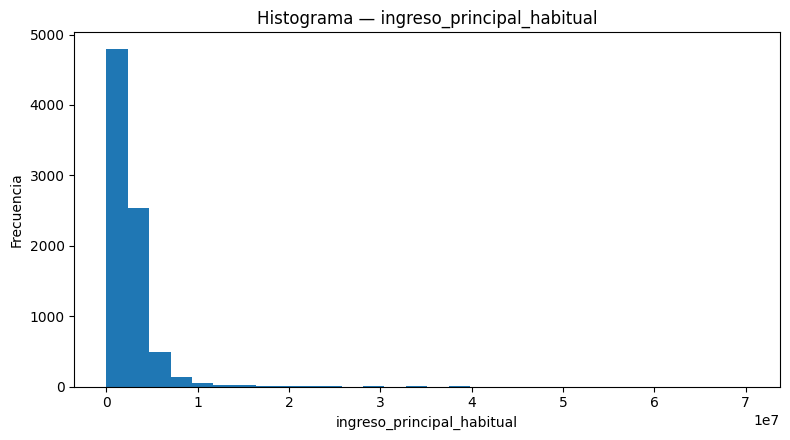

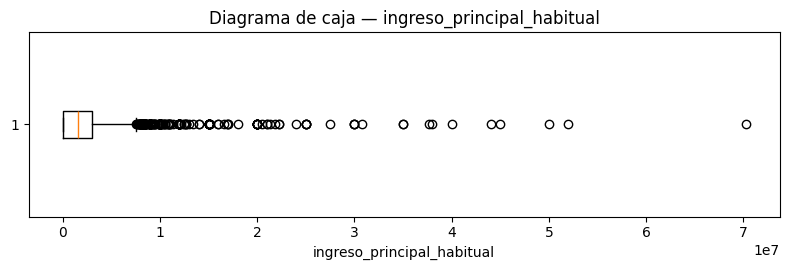

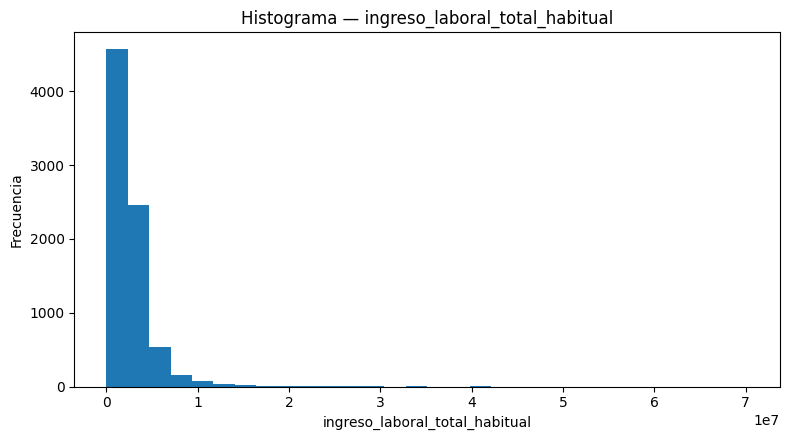

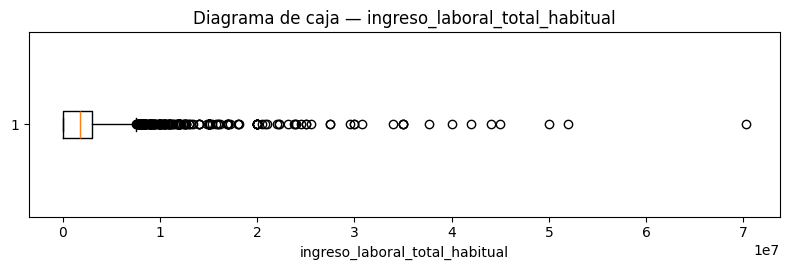

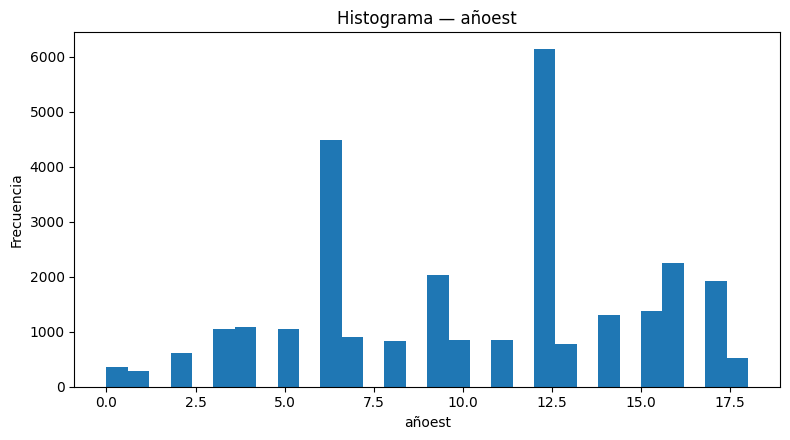

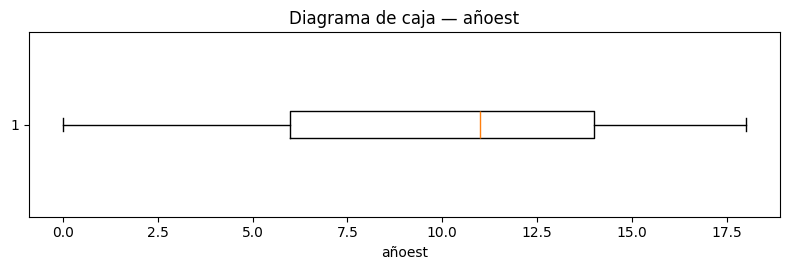

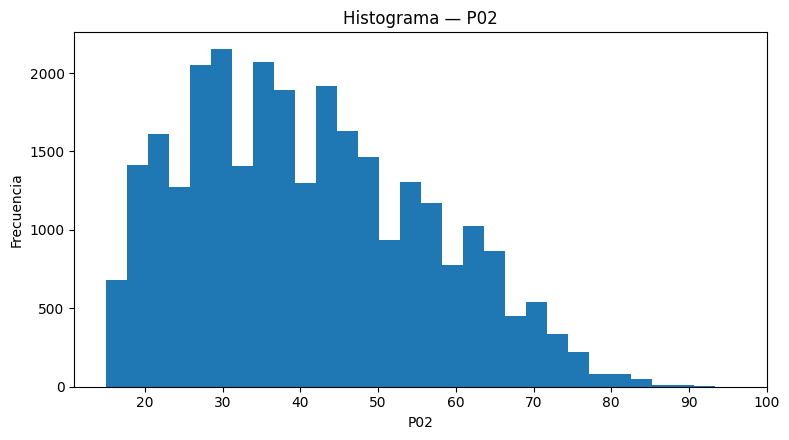

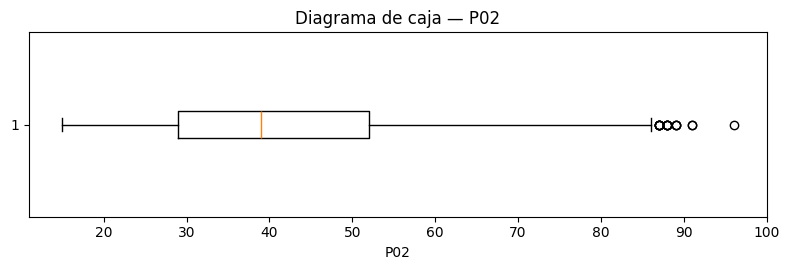

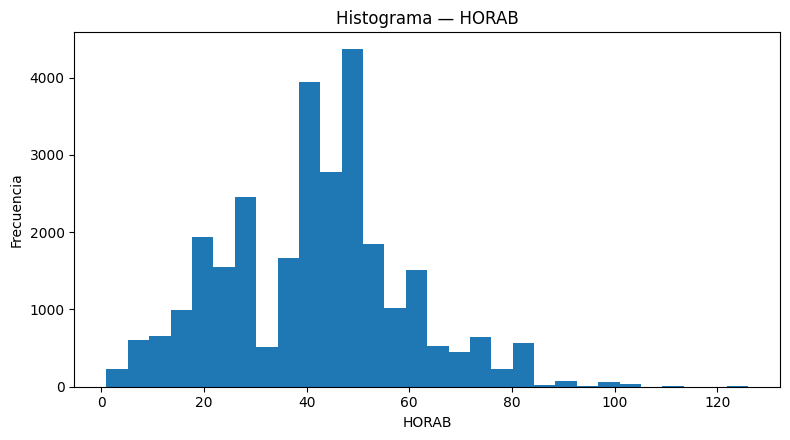

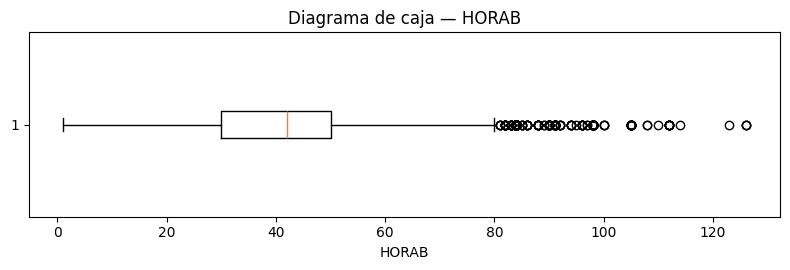

In [31]:
NUMERICAS_VISUAL = disponibles([
    "ingreso_principal_habitual",
    "ingreso_laboral_total_habitual",
    "añoest",
    "P02",
    "HORAB"
])

for c in NUMERICAS_VISUAL:
    s = pd.to_numeric(df3[c], errors="coerce").dropna()
    if s.empty:
        continue

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(s, bins=30)
    ax.set_title(f"Histograma — {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Frecuencia")
    fig.tight_layout()
    fig.savefig(CARPETA_ETAPA4 / f"hist_{clave(c)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 2.8))
    ax.boxplot(s, vert=False, showfliers=True)
    ax.set_title(f"Diagrama de caja — {c}")
    ax.set_xlabel(c)
    fig.tight_layout()
    fig.savefig(CARPETA_ETAPA4 / f"box_{clave(c)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 4.3 Análisis univariado — variables categóricas

Para cada variable categórica se calculan frecuencias absolutas y relativas. La **concentración** se mide como el porcentaje de observaciones acumulado por el 20 % de las categorías más frecuentes, usando `ceil(20 % de las categorías)` como número de categorías seleccionadas. Esto responde literalmente a cuánto del total explica ese grupo de categorías dominantes.


In [32]:
CATEGORICAS_ETAPA4 = disponibles([
    "estrato_educativo", "P06", "AREA",
    "CATE_PEA", "OCUP_PEA", "RAMA_PEA", "TAMA_PEA", "Informalidad",
    "B10", "B11", "B12A", "B13", "B14", "B15", "B26", "B28", "B29", "B30",
    "S01A", "S01B", "S02", "D01", "D03", "D04"
])

filas_cat = []
for c in CATEGORICAS_ETAPA4:
    s = df3[c].astype("string")
    f = s.dropna().value_counts()
    if f.empty:
        continue
    rel = f / f.sum() * 100
    n_cat = len(f)
    k20 = max(1, int(np.ceil(0.20 * n_cat)))
    top20 = f.iloc[:k20]
    pct_top20 = top20.sum() / f.sum() * 100
    acumulada = 0.0
    for categoria, n in f.items():
        acumulada += n / f.sum() * 100
        filas_cat.append({
            "variable": c,
            "categoria": categoria,
            "frecuencia": int(n),
            "porcentaje": rel.loc[categoria],
            "porcentaje_acumulado": acumulada,
            "n_categorias_total": n_cat,
            "k_20pct_categorias": k20,
            "porcentaje_explicado_top_20pct_categorias": pct_top20,
        })

univariado_categorico = pd.DataFrame(filas_cat)
display(univariado_categorico.head(80).round(3))
univariado_categorico.to_csv(NOMBRE_ETAPA4["cat"], index=False, encoding="utf-8")
print(f"Guardado: {NOMBRE_ETAPA4['cat'].relative_to(RAIZ)}")


,variable,categoria,frecuencia,porcentaje,porcentaje_acumulado,n_categorias_total,k_20pct_categorias,porcentaje_explicado_top_20pct_categorias
0,estrato_educativo,sin/básica,10646,37.344,37.344,3,1,37.344
1,estrato_educativo,terciaria/universitaria,9069,31.812,69.156,3,1,37.344
2,estrato_educativo,media,8793,30.844,100.000,3,1,37.344
3,P06,1,16451,57.251,57.251,2,1,57.251
4,P06,6,12284,42.749,100.000,2,1,57.251
5,AREA,1,16832,58.577,58.577,2,1,58.577
6,AREA,6,11903,41.423,100.000,2,1,58.577
7,CATE_PEA,2,11015,38.333,38.333,6,2,71.554
8,CATE_PEA,4,9546,33.221,71.554,6,2,71.554
9,CATE_PEA,1,2791,9.713,81.267,6,2,71.554


Guardado: output/etapa4/univariado_categorico.csv


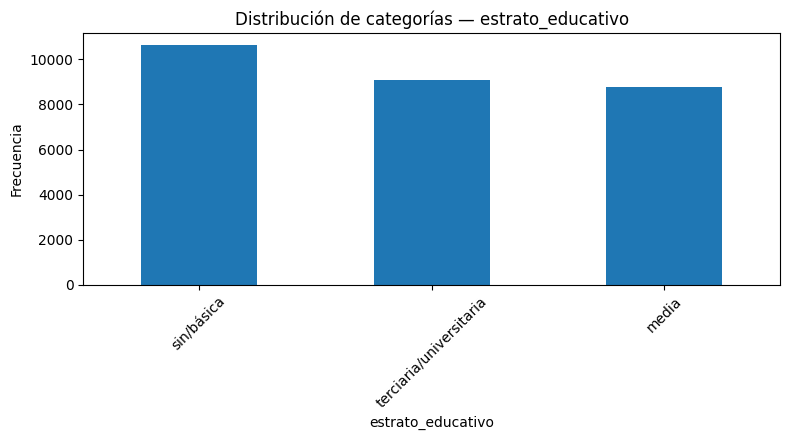

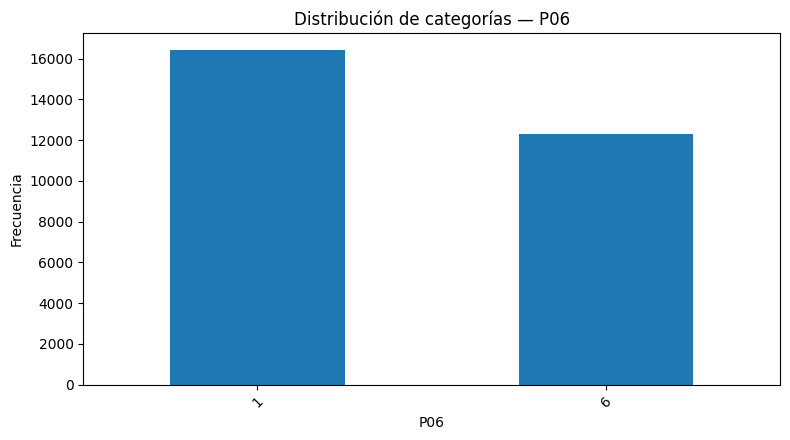

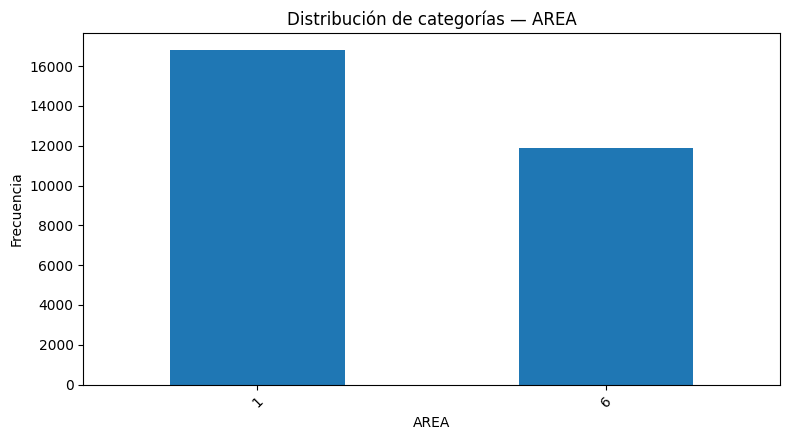

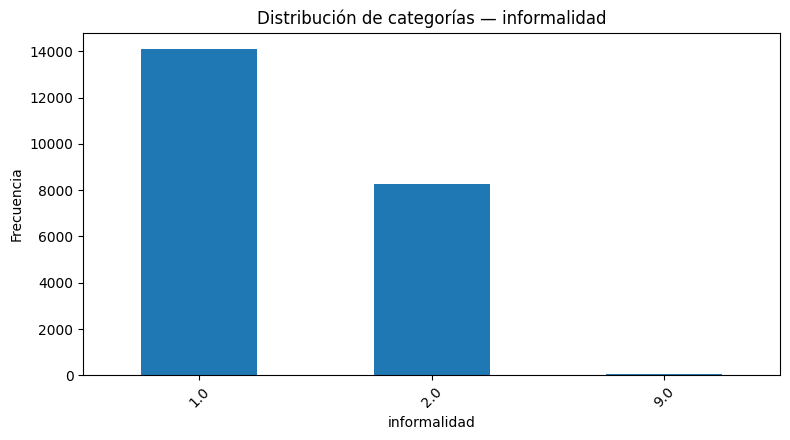

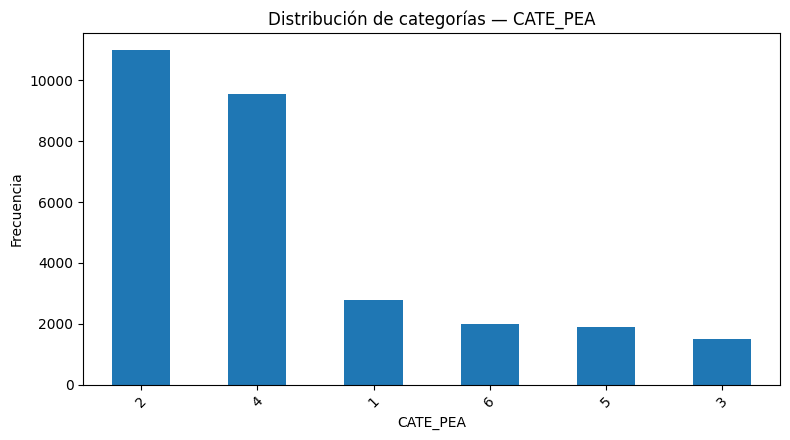

In [33]:
# 4.3.1 Gráficos de barras para las categorías principales
CATEGORICAS_VISUAL = disponibles([
    "estrato_educativo", "P06", "AREA", "Informalidad", "CATE_PEA"
])

for c in CATEGORICAS_VISUAL:
    f = df3[c].astype("string").dropna().value_counts().sort_values(ascending=False)
    if f.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4.5))
    f.plot(kind="bar", ax=ax)
    ax.set_title(f"Distribución de categorías — {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(CARPETA_ETAPA4 / f"bar_{clave(c)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 4.4 Bivariado — numérica frente a numérica

Se usan como variables principales las vinculadas directamente con la pregunta del proyecto: educación, ingreso, edad y jornada. Las correlaciones de **Pearson** captan asociación lineal; las de **Spearman** captan asociación monotónica y son menos sensibles a valores extremos.


,añoest,ED06C,P02,ingreso_principal_habitual,ingreso_laboral_total_habitual,HORAB
añoest,1.000,-0.588,-0.385,0.338,0.358,0.068
ED06C,-0.588,1.000,-0.228,-0.120,-0.139,0.098
P02,-0.385,-0.228,1.000,-0.004,0.003,-0.098
ingreso_principal_habitual,0.338,-0.120,-0.004,1.000,0.971,0.241
ingreso_laboral_total_habitual,0.358,-0.139,0.003,0.971,1.000,0.211
HORAB,0.068,0.098,-0.098,0.241,0.211,1.000


,añoest,ED06C,P02,ingreso_principal_habitual,ingreso_laboral_total_habitual,HORAB
añoest,1.000,-0.634,-0.357,0.419,0.430,0.061
ED06C,-0.634,1.000,-0.286,-0.272,-0.285,0.125
P02,-0.357,-0.286,1.000,-0.037,-0.031,-0.108
ingreso_principal_habitual,0.419,-0.272,-0.037,1.000,0.991,0.405
ingreso_laboral_total_habitual,0.430,-0.285,-0.031,0.991,1.000,0.385
HORAB,0.061,0.125,-0.108,0.405,0.385,1.000


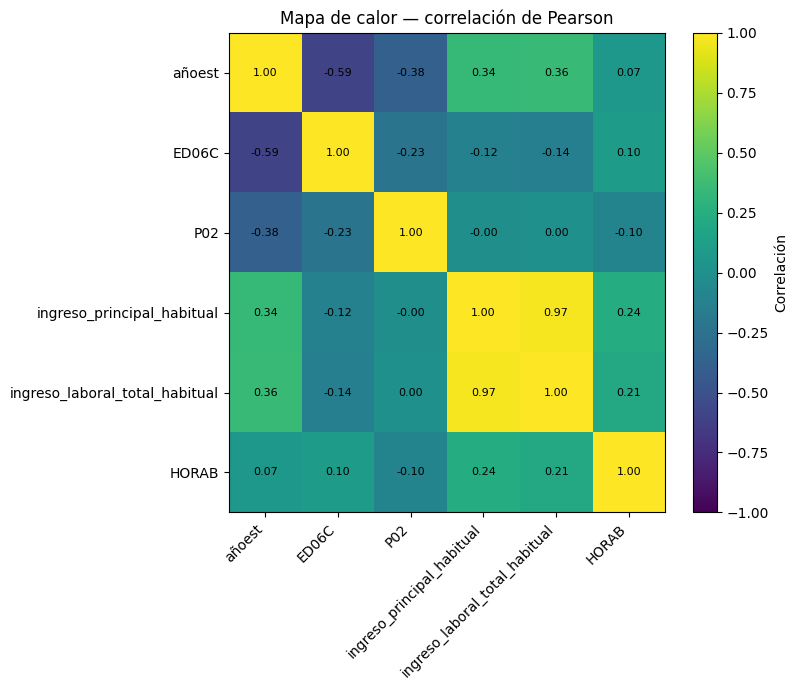

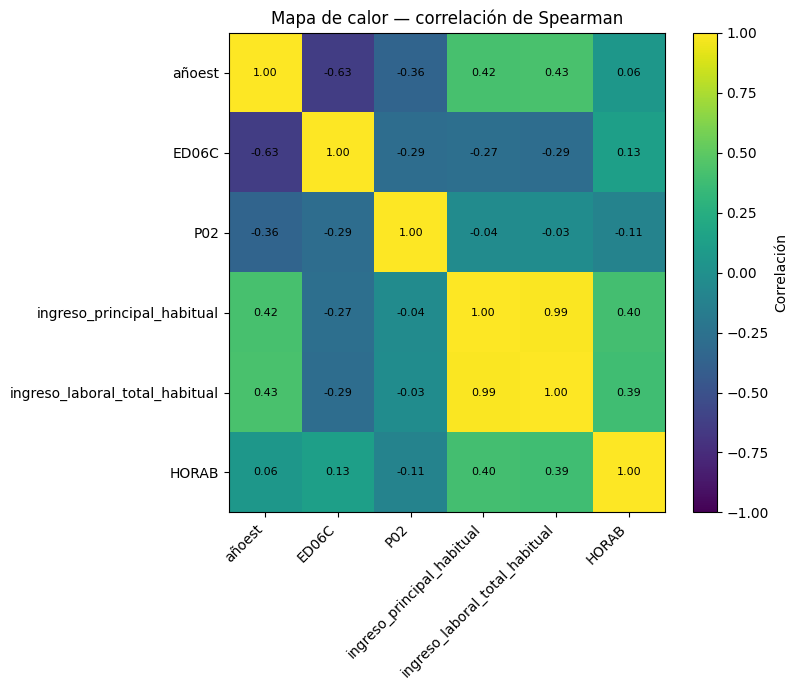

In [34]:
NUMERICAS_BIV = disponibles([
    "añoest", "ED06C", "P02", "ingreso_principal_habitual",
    "ingreso_laboral_total_habitual", "HORAB"
])

# Matrices de correlación de Pearson y Spearman.
pearson = df3[NUMERICAS_BIV].apply(pd.to_numeric, errors="coerce").corr(method="pearson")
spearman = df3[NUMERICAS_BIV].apply(pd.to_numeric, errors="coerce").corr(method="spearman")

pearson_long = pearson.stack().rename("pearson").reset_index()
spearman_long = spearman.stack().rename("spearman").reset_index()
correlaciones = pearson_long.merge(
    spearman_long, on=["level_0", "level_1"], how="outer"
).rename(columns={"level_0": "variable_1", "level_1": "variable_2"})

display(pearson.round(3))
display(spearman.round(3))
correlaciones.to_csv(NOMBRE_ETAPA4["corr"], index=False, encoding="utf-8")

# Heatmap de Pearson (sin dependencias adicionales).
def heatmap_correlacion(matriz, titulo, archivo):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(matriz.values, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(matriz.columns)), labels=matriz.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matriz.index)), labels=matriz.index)
    ax.set_title(titulo)
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            val = matriz.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Correlación")
    fig.tight_layout()
    fig.savefig(CARPETA_ETAPA4 / archivo, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

heatmap_correlacion(pearson, "Mapa de calor — correlación de Pearson", "heatmap_pearson.png")
heatmap_correlacion(spearman, "Mapa de calor — correlación de Spearman", "heatmap_spearman.png")


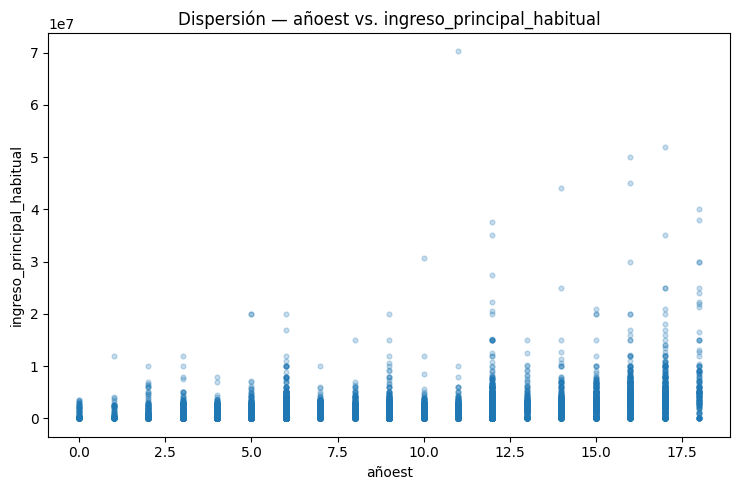

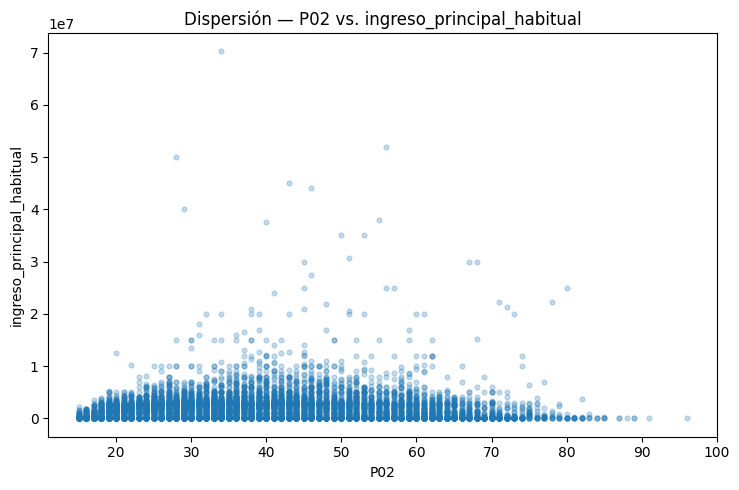

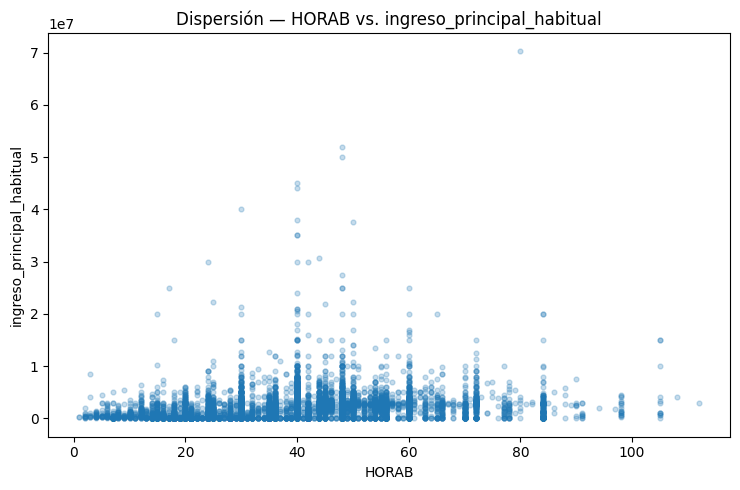

In [35]:
# 4.4.1 Diagramas de dispersión para relaciones sustantivas
PARES_DISPERSION = [
    ("añoest", "ingreso_principal_habitual"),
    ("P02", "ingreso_principal_habitual"),
    ("HORAB", "ingreso_principal_habitual"),
]

for xvar, yvar in PARES_DISPERSION:
    x, y = real4(xvar), real4(yvar)
    if x is None or y is None:
        continue
    xx = pd.to_numeric(df3[x], errors="coerce")
    yy = pd.to_numeric(df3[y], errors="coerce")
    m = xx.notna() & yy.notna()
    if m.sum() < 3:
        continue
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(xx.loc[m], yy.loc[m], alpha=0.25, s=12)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"Dispersión — {x} vs. {y}")
    fig.tight_layout()
    fig.savefig(CARPETA_ETAPA4 / f"scatter_{clave(x)}_vs_{clave(y)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 4.5 Bivariado — numérica frente a categórica

La comparación principal se realiza para el **ingreso laboral habitual** según estrato educativo, sexo, área e informalidad. Se reportan `n`, media, mediana, desvío estándar, mínimo, máximo e IQR por grupo, además del diagrama de caja para visualizar dispersión y valores extremos.


,variable_numerica,estrato_educativo,n,media,mediana,desvio_estandar,minimo,maximo,p25,p75,IQR,P06,AREA,informalidad
0,ingreso_principal_habitual,media,2524,1995733.108,2000000.0,2702460.211,0.0,70255000.0,0.0,2825250.0,2825250.0,<NA>,<NA>,<NA>
1,ingreso_principal_habitual,sin/básica,3182,1219515.980,600000.0,1659900.941,0.0,20000000.0,0.0,2000000.0,2000000.0,<NA>,<NA>,<NA>
2,ingreso_principal_habitual,terciaria/universitaria,2318,3507422.844,3000000.0,3885468.389,0.0,52000000.0,1500000.0,4500000.0,3000000.0,<NA>,<NA>,<NA>
3,ingreso_principal_habitual,<NA>,4142,2577688.827,2400000.0,3368663.752,0.0,70255000.0,600000.0,3200000.0,2600000.0,1,<NA>,<NA>
4,ingreso_principal_habitual,<NA>,3944,1627691.949,946312.5,2286623.160,0.0,40000000.0,0.0,2700000.0,2700000.0,6,<NA>,<NA>
5,ingreso_principal_habitual,<NA>,4436,2853984.895,2500000.0,3218977.155,0.0,52000000.0,1036000.0,3500000.0,2464000.0,<NA>,1,<NA>
6,ingreso_principal_habitual,<NA>,3650,1215377.308,300000.0,2227184.850,0.0,70255000.0,0.0,2000000.0,2000000.0,<NA>,6,<NA>
7,ingreso_principal_habitual,<NA>,3851,1792254.229,1600000.0,1704140.731,0.0,25000000.0,520000.0,2700000.0,2180000.0,<NA>,<NA>,1.0
8,ingreso_principal_habitual,<NA>,1916,4504778.203,3500000.0,3961361.136,280000.0,52000000.0,2778500.0,5000000.0,2221500.0,<NA>,<NA>,2.0
9,ingreso_principal_habitual,<NA>,8,3637250.000,2649000.0,2639320.895,2000000.0,10000000.0,2400000.0,3250000.0,850000.0,<NA>,<NA>,9.0


/tmp/ipykernel_1705/4180624481.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=grupos, showfliers=True)


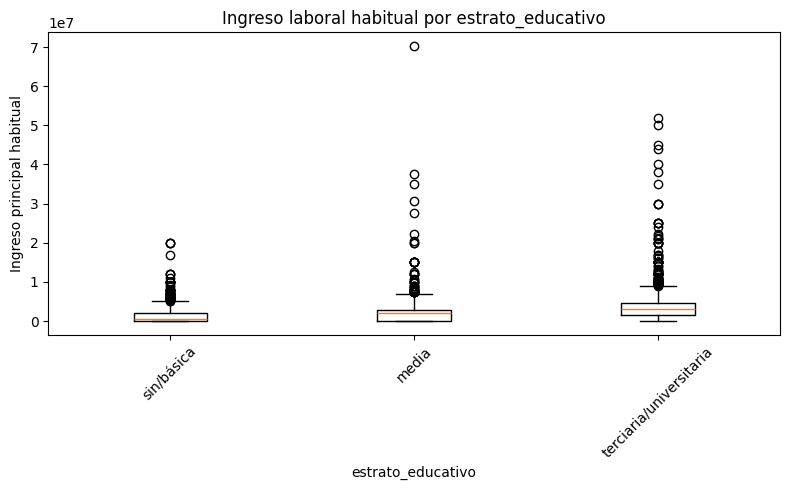

/tmp/ipykernel_1705/4180624481.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=grupos, showfliers=True)


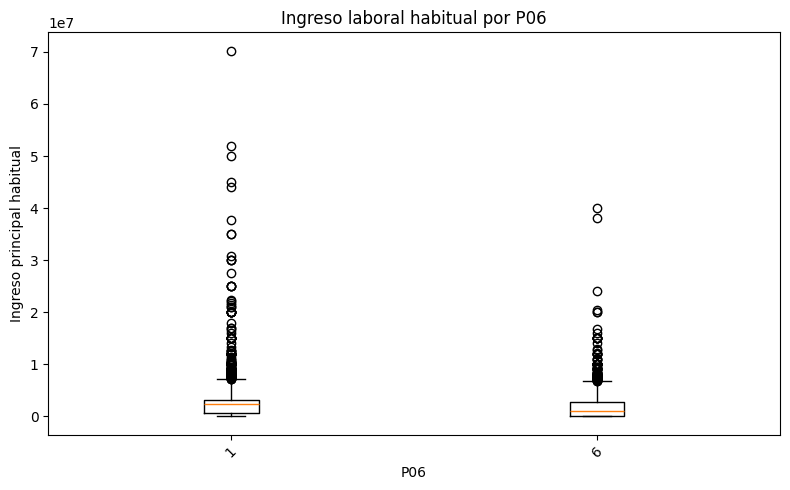

/tmp/ipykernel_1705/4180624481.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=grupos, showfliers=True)


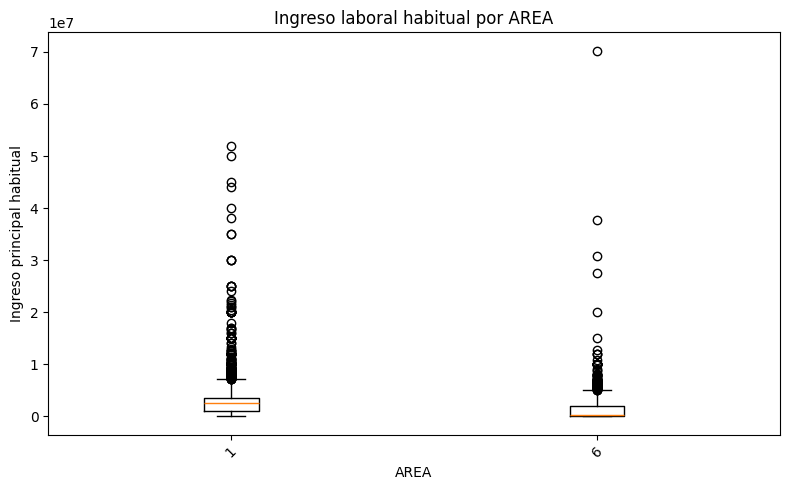

/tmp/ipykernel_1705/4180624481.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=grupos, showfliers=True)


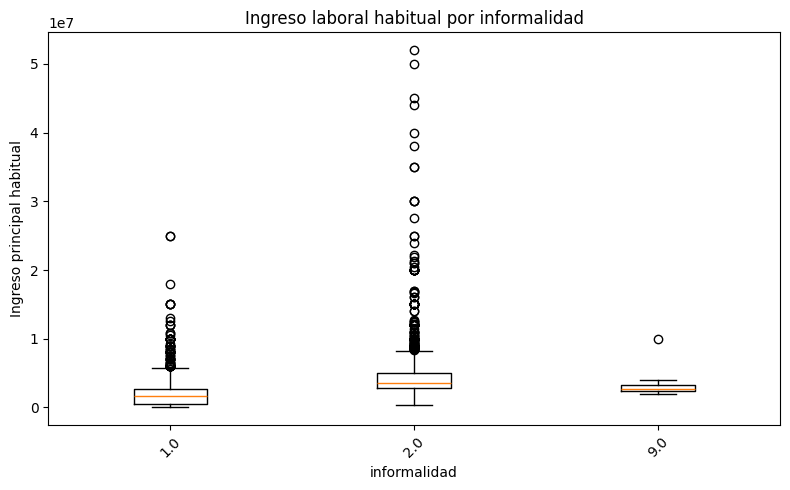

In [36]:
def resumen_num_por_cat(df, numerica, categorica):
    x = pd.to_numeric(df[numerica], errors="coerce")
    g = df[categorica].astype("string")
    tmp = pd.DataFrame({"x": x, "g": g}).dropna()
    if tmp.empty:
        return pd.DataFrame()
    out = (tmp.groupby("g", dropna=False)["x"]
           .agg(n="count", media="mean", mediana="median", desvio_estandar="std", minimo="min", maximo="max")
           .reset_index())
    q = tmp.groupby("g")["x"].quantile([.25, .75]).unstack()
    q.columns = ["p25", "p75"]
    out = out.merge(q.reset_index(), on="g", how="left")
    out["IQR"] = out["p75"] - out["p25"]
    out = out.rename(columns={"g": categorica})
    return out

INGRESO4 = real4("ingreso_principal_habitual")
CATEGORICAS_GRUPO = disponibles(["estrato_educativo", "P06", "AREA", "Informalidad"])

resumenes_biv = []
for cat in CATEGORICAS_GRUPO:
    r = resumen_num_por_cat(df3, INGRESO4, cat)
    if not r.empty:
        r.insert(0, "variable_numerica", INGRESO4)
        resumenes_biv.append(r)

if resumenes_biv:
    numerica_categorica_resumen = pd.concat(resumenes_biv, ignore_index=True)
else:
    numerica_categorica_resumen = pd.DataFrame()

display(numerica_categorica_resumen.round(3))
numerica_categorica_resumen.to_csv(NOMBRE_ETAPA4["biv_num_cat"], index=False, encoding="utf-8")

for cat in CATEGORICAS_GRUPO:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO4], errors="coerce"),
        "grupo": df3[cat].astype("string")
    }).dropna()
    if tmp.empty or tmp["grupo"].nunique() < 2:
        continue
    grupos = tmp["grupo"].value_counts().index.tolist()
    datos = [tmp.loc[tmp["grupo"] == g, "ingreso"] for g in grupos]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(datos, labels=grupos, showfliers=True)
    ax.set_title(f"Ingreso laboral habitual por {cat}")
    ax.set_xlabel(cat)
    ax.set_ylabel("Ingreso principal habitual")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(CARPETA_ETAPA4 / f"box_ingreso_por_{clave(cat)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 4.6 Bivariado — categórica frente a categórica

Para las relaciones principales se construyen tres tablas por cada cruce:
1. frecuencias absolutas;
2. porcentajes por fila;
3. porcentajes por columna.

La lectura correcta dependerá de qué variable se tome como denominador; por eso se conservan ambas normalizaciones.


In [37]:
def tablas_contingencia(df, fila, columna, prefijo):
    a = df[fila].astype("string")
    b = df[columna].astype("string")
    mask = a.notna() & b.notna()
    tabla_abs = pd.crosstab(a[mask], b[mask], dropna=False)
    tabla_fila = tabla_abs.div(tabla_abs.sum(axis=1), axis=0) * 100
    tabla_col = tabla_abs.div(tabla_abs.sum(axis=0), axis=1) * 100

    tabla_abs.to_csv(CARPETA_ETAPA4 / f"{prefijo}_absoluta.csv", encoding="utf-8")
    tabla_fila.to_csv(CARPETA_ETAPA4 / f"{prefijo}_por_fila_pct.csv", encoding="utf-8")
    tabla_col.to_csv(CARPETA_ETAPA4 / f"{prefijo}_por_columna_pct.csv", encoding="utf-8")

    print(f"\n### {fila} x {columna} — frecuencias absolutas")
    display(tabla_abs)
    print("### Porcentajes por fila")
    display(tabla_fila.round(2))
    print("### Porcentajes por columna")
    display(tabla_col.round(2))

CRUCES_CAT = [
    ("estrato_educativo", "P06"),
    ("estrato_educativo", "AREA"),
    ("estrato_educativo", "Informalidad"),
]

for fila, columna in CRUCES_CAT:
    f, c = real4(fila), real4(columna)
    if f is not None and c is not None:
        tablas_contingencia(df3, f, c, f"cont_{clave(f)}_x_{clave(c)}")



### estrato_educativo x P06 — frecuencias absolutas


P06,1,6
estrato_educativo,,
media,5507,3286
sin/básica,6564,4082
terciaria/universitaria,4255,4814


### Porcentajes por fila


P06,1,6
estrato_educativo,,
media,62.63,37.37
sin/básica,61.66,38.34
terciaria/universitaria,46.92,53.08


### Porcentajes por columna


...

informalidad,1.0,2.0,9.0
estrato_educativo,,,
media,5049,2389,19
sin/básica,5409,875,9
terciaria/universitaria,3550,4981,22


### Porcentajes por fila


informalidad,1.0,2.0,9.0
estrato_educativo,,,
media,67.71,32.04,0.25
sin/básica,85.95,13.90,0.14
terciaria/universitaria,41.51,58.24,0.26


### Porcentajes por columna


informalidad,1.0,2.0,9.0
estrato_educativo,,,
media,36.04,28.98,38.0
sin/básica,38.61,10.61,18.0
terciaria/universitaria,25.34,60.41,44.0


## 4.7 Análisis temporal

**No corresponde construir serie temporal semanal o mensual.** La base utilizada es la EPHC **anual 2025** y, dentro de las variables conservadas para este proyecto, no existe una fecha de observación mensual/semanal ni una variable de período repetido que permita ordenar observaciones en el tiempo. `P08A` representa el año de nacimiento y no el momento de observación.

Por lo tanto, crear una media móvil, estacionalidad semanal/mensual o quiebres temporales a partir de `P08A` sería metodológicamente incorrecto. Esta ausencia se documenta explícitamente en lugar de fabricar una serie temporal.


In [38]:
# 4.7.1 Registro reproducible de aplicabilidad temporal
analisis_temporal = pd.DataFrame([{
    "analisis": "serie temporal con media móvil",
    "aplica": False,
    "fundamento": "EPHC anual 2025; no hay fecha semanal/mensual de observación en las variables conservadas."
}, {
    "analisis": "estacionalidad semanal",
    "aplica": False,
    "fundamento": "La encuesta es anual y las variables de día de semana no fueron conservadas en la selección analítica."
}, {
    "analisis": "estacionalidad mensual",
    "aplica": False,
    "fundamento": "No existe un mes de observación para construir una serie temporal de 2025."
}, {
    "analisis": "identificación de tendencias y quiebres",
    "aplica": False,
    "fundamento": "Con una sola medición anual no se dispone de una secuencia temporal suficiente."
}])

display(analisis_temporal)
analisis_temporal.to_csv(CARPETA_ETAPA4 / "analisis_temporal.csv", index=False, encoding="utf-8")


,analisis,aplica,fundamento
0,serie temporal con media móvil,False,EPHC anual 2025; no hay fecha semanal/mensual de observación en las variables conservadas.
1,estacionalidad semanal,False,La encuesta es anual y las variables de día de semana no fueron conservadas en la selección anal...
2,estacionalidad mensual,False,No existe un mes de observación para construir una serie temporal de 2025.
3,identificación de tendencias y quiebres,False,Con una sola medición anual no se dispone de una secuencia temporal suficiente.


## 4.8 Cierre y archivos generados

La Etapa 4 deja una salida reproducible para cada bloque solicitado en la guía. Los gráficos se guardan como PNG y las tablas como CSV dentro de `output/etapa4/`.

La interpretación sustantiva para la pregunta principal debe hacerse a partir de estos resultados, especialmente comparando la distribución del ingreso laboral habitual entre `estrato_educativo` y revisando cómo cambian las asociaciones al controlar descriptivamente por edad, jornada, sexo, área e informalidad en las etapas posteriores.


# Fase 1 · Etapa 5 — Análisis descriptivo y exploratorio integrado

Esta etapa integra los resultados de las Etapas 3 y 4 para caracterizar el fenómeno central del proyecto: **la relación descriptiva entre nivel educativo e ingresos laborales de la Población Económicamente Activa (PEA) de 15 años o más en Paraguay durante 2025**.

La etapa no pretende demostrar causalidad. Los patrones descriptivos y exploratorios se transformarán en hipótesis que serán contrastadas formalmente en la Fase 2.

**Criterio temporal:** la EPHC utilizada es anual 2025. Por ello, no existe una secuencia mensual o semanal de observaciones. La única dimensión temporal conservada es `P08A`, año de nacimiento, que se utiliza como **cohorte**. La figura por cohorte se interpreta como una comparación descriptiva entre generaciones y no como una tendencia temporal del mercado laboral durante 2025.

In [39]:
# 5.1 Configuración y funciones auxiliares
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from pathlib import Path

CARPETA_ETAPA5 = RAIZ / "output" / "etapa5"
CARPETA_ETAPA5.mkdir(parents=True, exist_ok=True)

def real5(nombre):
    """Resuelve el nombre de una variable dentro de df3."""
    if nombre in df3.columns:
        return nombre
    if "clave" in globals():
        k = clave(nombre)
        candidatos = [c for c in df3.columns if clave(c) == k]
        return candidatos[0] if candidatos else None
    return None

def disp5(lista):
    return [v for v in (real5(x) for x in lista) if v is not None]

def num5(nombre):
    c = real5(nombre)
    if c is None:
        return None
    return pd.to_numeric(df3[c], errors="coerce")

def guardar_fig(fig, nombre):
    ruta = CARPETA_ETAPA5 / nombre
    fig.savefig(ruta, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return ruta

def interpretar(texto):
    display(Markdown("**Interpretación.** " + texto))

INGRESO5 = real5("ingreso_principal_habitual")
EDUCACION5 = real5("añoest")
ESTRATO5 = real5("estrato_educativo")
EDAD5 = real5("P02")
SEXO5 = real5("P06")
AREA5 = real5("AREA")
INFORMAL5 = real5("Informalidad")
COHORTE5 = real5("P08A")
FACTOR5 = real5("Factor")

print(f"Registros disponibles para Etapa 5: {len(df3):,}")
print("Ingreso:", INGRESO5)
print("Años de estudio:", EDUCACION5)
print("Estrato educativo:", ESTRATO5)
print("Edad:", EDAD5)
print("Sexo:", SEXO5)
print("Área:", AREA5)
print("Informalidad:", INFORMAL5)
print("Año de nacimiento/cohorte:", COHORTE5)

Registros disponibles para Etapa 5: 28,735
Ingreso: ingreso_principal_habitual
Años de estudio: añoest
Estrato educativo: estrato_educativo
Edad: P02
Sexo: P06
Área: AREA
Informalidad: informalidad
Año de nacimiento/cohorte: P08A


## 5.2 Visualización 1 — Histograma del ingreso laboral habitual

El histograma permite observar la forma de la distribución del ingreso principal habitual, en guaraníes mensuales. Se complementa con la mediana y la media para evaluar si la distribución presenta asimetría suficiente para que la mediana sea un resumen más representativo.

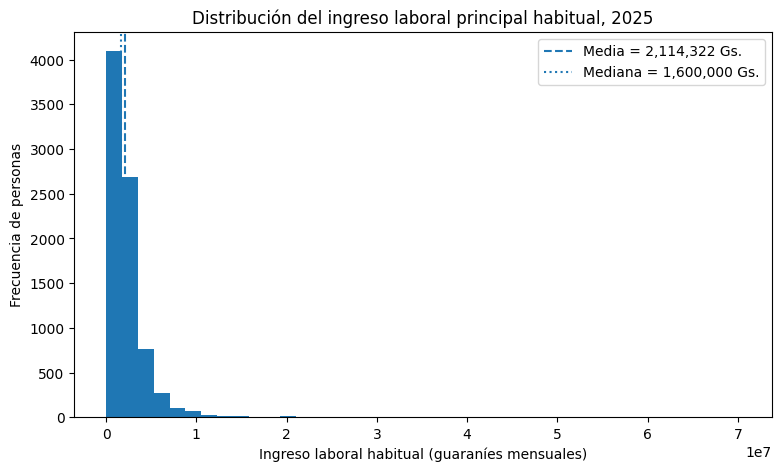

**Interpretación.** La media es 2,114,322 Gs. y la mediana 1,600,000 Gs. La diferencia entre ambas es consistente con una distribución sesgada hacia valores altos; por eso la mediana resulta más representativa del ingreso típico.

In [40]:
# Visualización 1: histograma del ingreso
s = pd.to_numeric(df3[INGRESO5], errors="coerce").dropna()
media = s.mean()
mediana = s.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(s, bins=40)
ax.axvline(media, linestyle="--", label=f"Media = {media:,.0f} Gs.")
ax.axvline(mediana, linestyle=":", label=f"Mediana = {mediana:,.0f} Gs.")
ax.set_title("Distribución del ingreso laboral principal habitual, 2025")
ax.set_xlabel("Ingreso laboral habitual (guaraníes mensuales)")
ax.set_ylabel("Frecuencia de personas")
ax.legend()
ruta = guardar_fig(fig, "01_histograma_ingreso_habitual.png")

interpretar(
    f"La media es {media:,.0f} Gs. y la mediana {mediana:,.0f} Gs. "
    + ("La diferencia entre ambas es consistente con una distribución sesgada hacia valores altos; por eso la mediana resulta más representativa del ingreso típico."
       if media > mediana else
       "La media no supera a la mediana; la conveniencia relativa de ambos resúmenes debe evaluarse junto con la asimetría calculada en la Etapa 4.")
)

## 5.3 Visualización 2 — Diagrama de caja del ingreso por estrato educativo

Esta figura concentra la comparación que responde directamente al objetivo principal: cómo cambia el nivel y la dispersión del ingreso laboral según el estrato educativo.

/tmp/ipykernel_1705/2231830004.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=orden, showfliers=False)


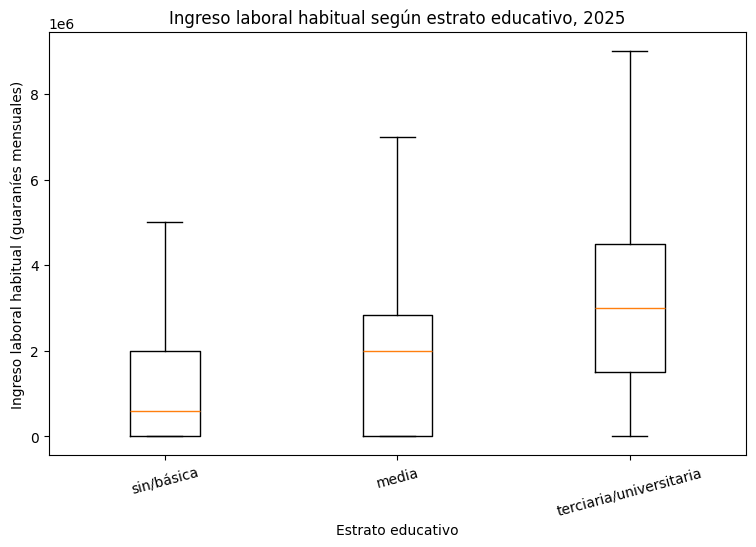

**Interpretación.** Las posiciones de las cajas y sus medianas muestran cómo cambia el ingreso típico entre estratos. Una separación amplia entre medianas, acompañada por diferencias en IQR, aporta evidencia descriptiva de heterogeneidad asociada al nivel educativo, sin implicar causalidad.

In [41]:
# Visualización 2: boxplot de ingreso por educación
if INGP:=INGRESO5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "educacion": df3[ESTRATO5].astype("string") if ESTRATO5 else pd.Series(pd.NA, index=df3.index)
    }).dropna()
    if not tmp.empty:
        orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in tmp["educacion"].unique()]
        if len(orden) < 2:
            orden = tmp["educacion"].value_counts().index.tolist()
        datos = [tmp.loc[tmp["educacion"] == g, "ingreso"] for g in orden]
        med = tmp.groupby("educacion")["ingreso"].median()
        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.boxplot(datos, labels=orden, showfliers=False)
        ax.set_title("Ingreso laboral habitual según estrato educativo, 2025")
        ax.set_xlabel("Estrato educativo")
        ax.set_ylabel("Ingreso laboral habitual (guaraníes mensuales)")
        ax.tick_params(axis="x", rotation=15)
        ruta = guardar_fig(fig, "02_boxplot_ingreso_por_estrato.png")
        if len(orden) >= 2:
            interpretar(
                "Las posiciones de las cajas y sus medianas muestran cómo cambia el ingreso típico entre estratos. "
                "Una separación amplia entre medianas, acompañada por diferencias en IQR, aporta evidencia descriptiva de heterogeneidad asociada al nivel educativo, sin implicar causalidad."
            )

## 5.4 Visualización 3 — Diagrama de dispersión entre años de estudio e ingreso

La relación entre `añoest` e ingreso se observa como una nube de puntos. Se agrega una línea de tendencia lineal únicamente como apoyo visual; no constituye una estimación causal.

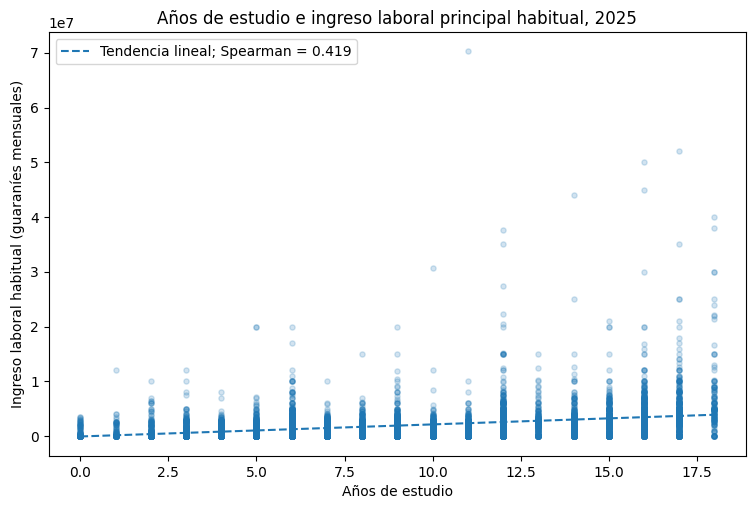

**Interpretación.** La asociación monotónica entre años de estudio e ingreso presenta un coeficiente de Spearman de 0.419. La nube muestra si la relación es aproximadamente creciente, débil o heterogénea; la dispersión residual confirma que la educación no es la única dimensión asociada al ingreso.

In [42]:
# Visualización 3: dispersión años de estudio vs ingreso
if EDUCACION5 and INGRESO5:
    x = pd.to_numeric(df3[EDUCACION5], errors="coerce")
    y = pd.to_numeric(df3[INGRESO5], errors="coerce")
    m = x.notna() & y.notna() & (y >= 0)
    if m.sum() >= 3:
        xx, yy = x[m], y[m]
        coef = np.polyfit(xx, yy, 1)
        xline = np.linspace(xx.min(), xx.max(), 100)
        yline = coef[0] * xline + coef[1]
        rho = xx.corr(yy, method="spearman")
        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.scatter(xx, yy, alpha=0.20, s=14)
        ax.plot(xline, yline, linestyle="--", label=f"Tendencia lineal; Spearman = {rho:.3f}")
        ax.set_title("Años de estudio e ingreso laboral principal habitual, 2025")
        ax.set_xlabel("Años de estudio")
        ax.set_ylabel("Ingreso laboral habitual (guaraníes mensuales)")
        ax.legend()
        ruta = guardar_fig(fig, "03_dispersion_estudio_vs_ingreso.png")
        interpretar(
            f"La asociación monotónica entre años de estudio e ingreso presenta un coeficiente de Spearman de {rho:.3f}. "
            "La nube muestra si la relación es aproximadamente creciente, débil o heterogénea; la dispersión residual confirma que la educación no es la única dimensión asociada al ingreso."
        )

## 5.5 Visualización 4 — Barras comparativas del ingreso mediano por educación y sexo

Se utiliza la mediana porque el ingreso presenta potencial asimetría. La comparación simultánea por estrato educativo y sexo permite explorar si la brecha descriptiva asociada a educación se comporta de manera similar entre hombres y mujeres.

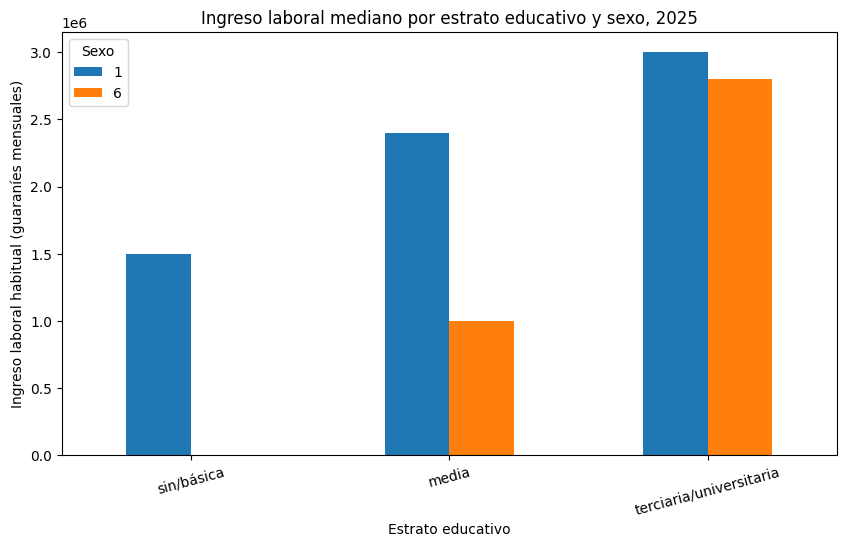

**Interpretación.** El gráfico permite verificar si las diferencias de ingreso entre estratos educativos se mantienen dentro de cada sexo. Una separación persistente entre grupos debe interpretarse como asociación descriptiva y será una candidata a contraste formal en la Fase 2.

In [43]:
# Visualización 4: barras comparativas por educación y sexo
if INGRESO5 and ESTRATO5 and SEXO5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "educacion": df3[ESTRATO5].astype("string"),
        "sexo": df3[SEXO5].astype("string")
    }).dropna()
    if not tmp.empty and tmp["educacion"].nunique() >= 2 and tmp["sexo"].nunique() >= 2:
        tab = tmp.pivot_table(index="educacion", columns="sexo", values="ingreso", aggfunc="median")
        orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in tab.index]
        if len(orden) >= 2:
            tab = tab.reindex(orden)
        ax = tab.plot(kind="bar", figsize=(10, 5.5))
        ax.set_title("Ingreso laboral mediano por estrato educativo y sexo, 2025")
        ax.set_xlabel("Estrato educativo")
        ax.set_ylabel("Ingreso laboral habitual (guaraníes mensuales)")
        ax.legend(title="Sexo")
        ax.tick_params(axis="x", rotation=15)
        ruta = guardar_fig(ax.get_figure(), "04_barras_ingreso_educacion_sexo.png")
        interpretar(
            "El gráfico permite verificar si las diferencias de ingreso entre estratos educativos se mantienen dentro de cada sexo. "
            "Una separación persistente entre grupos debe interpretarse como asociación descriptiva y será una candidata a contraste formal en la Fase 2."
        )

## 5.6 Visualización 5 — Mapa de calor de correlaciones

Se resumen las asociaciones lineales y monotónicas entre educación, edad, jornada e ingresos. La escala está fijada entre -1 y 1 para evitar distorsionar la comparación.

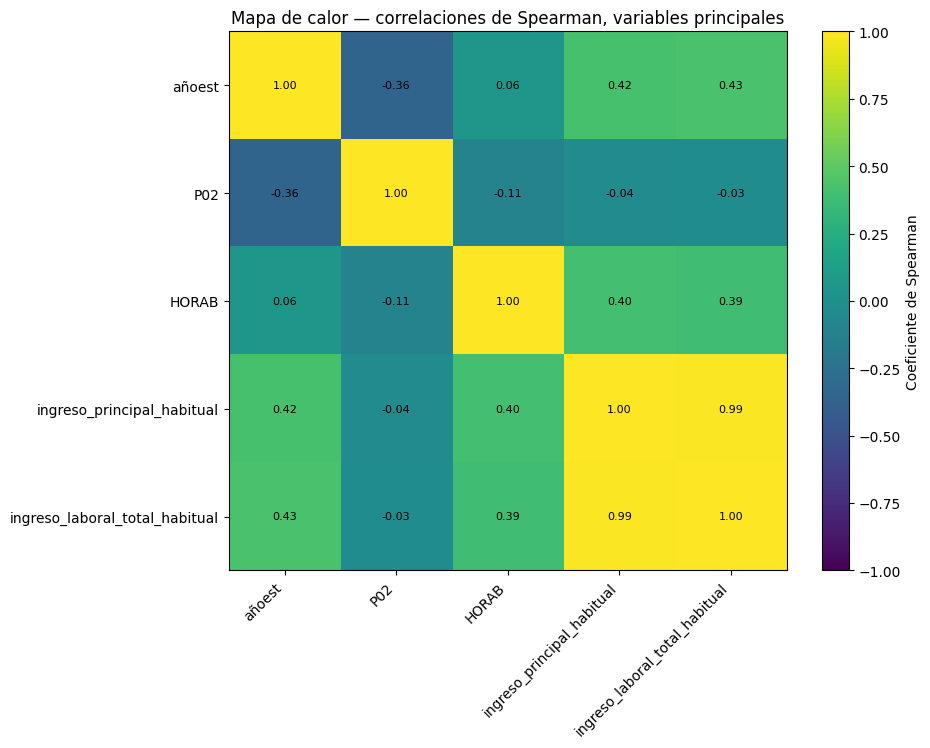

**Interpretación.** La correlación de Spearman entre años de estudio e ingreso es 0.419. El mapa también permite observar qué otras variables mantienen asociaciones relevantes con el ingreso y cuáles podrían ser importantes como controles en la Fase 2.

In [44]:
# Visualización 5: heatmap de correlación de Spearman
corr_vars = disp5(["añoest", "P02", "HORAB", "ingreso_principal_habitual", "ingreso_laboral_total_habitual"])
if len(corr_vars) >= 2:
    matriz_s = df3[corr_vars].apply(pd.to_numeric, errors="coerce").corr(method="spearman")
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(matriz_s.values, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(matriz_s.columns)), labels=matriz_s.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matriz_s.index)), labels=matriz_s.index)
    ax.set_title("Mapa de calor — correlaciones de Spearman, variables principales")
    for i in range(matriz_s.shape[0]):
        for j in range(matriz_s.shape[1]):
            v = matriz_s.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Coeficiente de Spearman")
    ruta = guardar_fig(fig, "05_heatmap_spearman.png")
    if INGRESO5 and EDUCACION5:
        rho = pd.to_numeric(df3[EDUCACION5], errors="coerce").corr(
            pd.to_numeric(df3[INGRESO5], errors="coerce"), method="spearman"
        )
        interpretar(
            f"La correlación de Spearman entre años de estudio e ingreso es {rho:.3f}. "
            "El mapa también permite observar qué otras variables mantienen asociaciones relevantes con el ingreso y cuáles podrían ser importantes como controles en la Fase 2."
        )

## 5.7 Visualización 6 — Distribución porcentual de educación por área de residencia

El gráfico comparativo permite detectar diferencias en la composición educativa entre áreas urbana y rural. Se muestran porcentajes dentro de cada área, por lo que las columnas suman 100 %.

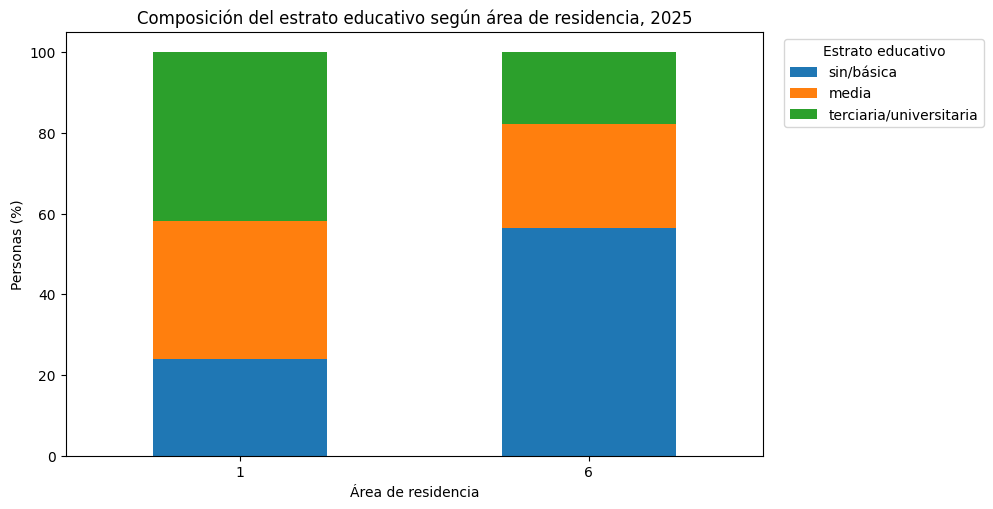

**Interpretación.** La composición porcentual evidencia si la estructura educativa difiere entre áreas de residencia. Estas diferencias son relevantes porque el área puede estar asociada simultáneamente con oportunidades laborales e ingresos, por lo que deberá considerarse como dimensión de control en la Fase 2.

In [45]:
# Visualización 6: composición educativa por área
if ESTRATO5 and AREA5:
    tmp = pd.DataFrame({
        "educacion": df3[ESTRATO5].astype("string"),
        "area": df3[AREA5].astype("string")
    }).dropna()
    if not tmp.empty and tmp["area"].nunique() >= 2:
        tab = pd.crosstab(tmp["area"], tmp["educacion"], normalize="index") * 100
        orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in tab.columns]
        if orden:
            tab = tab.reindex(columns=orden)
        ax = tab.plot(kind="bar", stacked=True, figsize=(9, 5.5))
        ax.set_title("Composición del estrato educativo según área de residencia, 2025")
        ax.set_xlabel("Área de residencia")
        ax.set_ylabel("Personas (%)")
        ax.legend(title="Estrato educativo", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=0)
        ruta = guardar_fig(ax.get_figure(), "06_composicion_educativa_por_area.png")
        interpretar(
            "La composición porcentual evidencia si la estructura educativa difiere entre áreas de residencia. "
            "Estas diferencias son relevantes porque el área puede estar asociada simultáneamente con oportunidades laborales e ingresos, por lo que deberá considerarse como dimensión de control en la Fase 2."
        )

## 5.8 Visualización 7 — Ingreso por condición de informalidad

La comparación permite observar si la informalidad está asociada con un nivel y una dispersión del ingreso diferentes. Se muestran distribuciones por grupo y no únicamente promedios.

/tmp/ipykernel_1705/1647220214.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=grupos, showfliers=False)


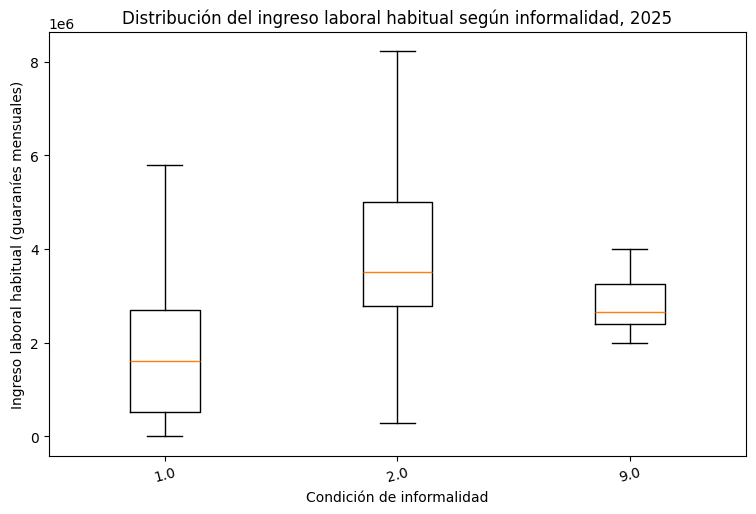

**Interpretación.** Las medianas y el ancho de las cajas permiten evaluar si la distribución del ingreso difiere entre trabajadores formales e informales. Esta variable puede actuar como un mecanismo o una dimensión asociada al vínculo entre educación y resultados laborales; su papel causal deberá determinarse en la Fase 2.

In [46]:
# Visualización 7: boxplot por informalidad
if INGRESO5 and INFORMAL5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "informalidad": df3[INFORMAL5].astype("string")
    }).dropna()
    if not tmp.empty and tmp["informalidad"].nunique() >= 2:
        grupos = tmp["informalidad"].value_counts().index.tolist()
        datos = [tmp.loc[tmp["informalidad"] == g, "ingreso"] for g in grupos]
        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.boxplot(datos, labels=grupos, showfliers=False)
        ax.set_title("Distribución del ingreso laboral habitual según informalidad, 2025")
        ax.set_xlabel("Condición de informalidad")
        ax.set_ylabel("Ingreso laboral habitual (guaraníes mensuales)")
        ax.tick_params(axis="x", rotation=15)
        ruta = guardar_fig(fig, "07_boxplot_ingreso_informalidad.png")
        meds = tmp.groupby("informalidad")["ingreso"].median().sort_values()
        interpretar(
            "Las medianas y el ancho de las cajas permiten evaluar si la distribución del ingreso difiere entre trabajadores formales e informales. "
            "Esta variable puede actuar como un mecanismo o una dimensión asociada al vínculo entre educación y resultados laborales; su papel causal deberá determinarse en la Fase 2."
        )

## 5.9 Visualización 8 — Serie por cohorte de nacimiento

`P08A` se interpreta como año de nacimiento. Se agrupan los casos en cohortes quinquenales y se grafica la **mediana del ingreso laboral observado en 2025** para cada cohorte. Esto satisface la dimensión temporal requerida sin convertir el año de nacimiento en una falsa fecha de observación.

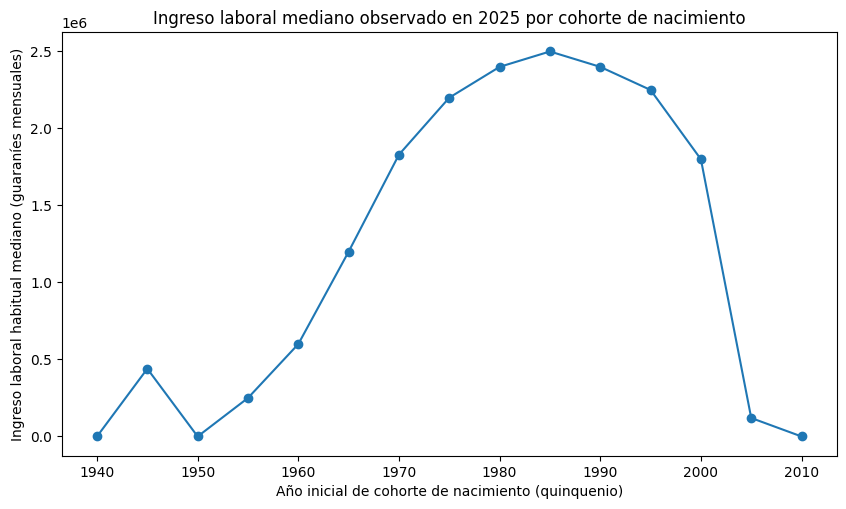

**Interpretación.** La figura compara generaciones de nacimiento presentes en la muestra 2025. No debe leerse como una tendencia del ingreso a lo largo del tiempo, porque cada punto corresponde a personas observadas en el mismo año 2025; las diferencias pueden combinar edad, trayectoria y efectos de cohorte.

In [47]:
# Visualización 8: serie por cohorte de nacimiento
if COHORTE5 and INGRESO5:
    tmp = pd.DataFrame({
        "cohorte": pd.to_numeric(df3[COHORTE5], errors="coerce"),
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce")
    }).dropna()
    tmp = tmp[(tmp["ingreso"] >= 0) & tmp["cohorte"].between(1900, 2010)]
    if len(tmp) >= 20:
        tmp["cohorte_5"] = (tmp["cohorte"] // 5 * 5).astype(int)
        coh = tmp.groupby("cohorte_5").agg(
            n=("ingreso", "size"),
            mediana_ingreso=("ingreso", "median")
        ).reset_index()
        coh = coh[coh["n"] >= 20]
        if len(coh) >= 2:
            fig, ax = plt.subplots(figsize=(10, 5.5))
            ax.plot(coh["cohorte_5"], coh["mediana_ingreso"], marker="o")
            ax.set_title("Ingreso laboral mediano observado en 2025 por cohorte de nacimiento")
            ax.set_xlabel("Año inicial de cohorte de nacimiento (quinquenio)")
            ax.set_ylabel("Ingreso laboral habitual mediano (guaraníes mensuales)")
            ruta = guardar_fig(fig, "08_serie_cohortes_nacimiento.png")
            interpretar(
                "La figura compara generaciones de nacimiento presentes en la muestra 2025. "
                "No debe leerse como una tendencia del ingreso a lo largo del tiempo, porque cada punto corresponde a personas observadas en el mismo año 2025; las diferencias pueden combinar edad, trayectoria y efectos de cohorte."
            )

## 5.10 Visualización adicional — Proporción de informalidad por estrato educativo

Se agrega una novena visualización para reforzar la caracterización del mercado laboral y el vínculo con el objetivo de calidad de la ocupación.

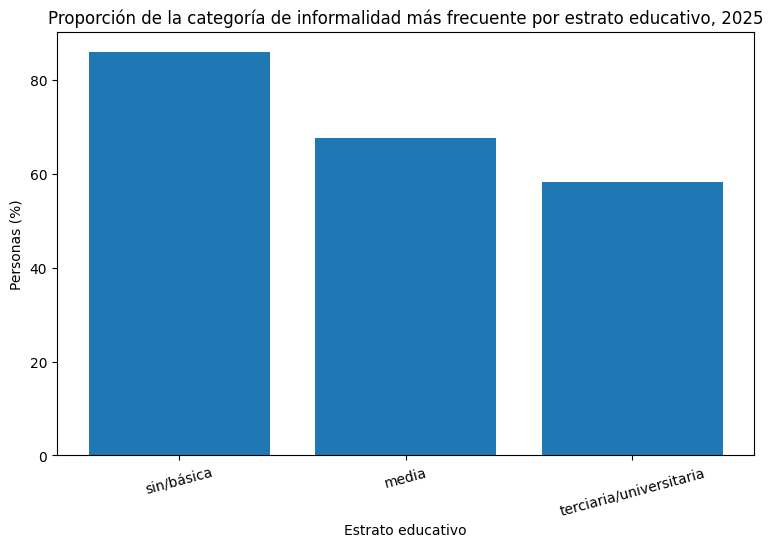

**Interpretación.** La figura muestra cómo cambia la composición de la informalidad entre estratos educativos. Una concentración sistemática de informalidad en determinados niveles educativos aporta evidencia complementaria para estudiar mecanismos del diferencial de ingresos.

In [48]:
# Visualización 9: informalidad por estrato educativo
if ESTRATO5 and INFORMAL5:
    tmp = pd.DataFrame({
        "educacion": df3[ESTRATO5].astype("string"),
        "informalidad": df3[INFORMAL5].astype("string")
    }).dropna()
    if not tmp.empty and tmp["educacion"].nunique() >= 2:
        tab = pd.crosstab(tmp["educacion"], tmp["informalidad"], normalize="index") * 100
        col = tab.columns.tolist()
        etiqueta = col[-1]
        if len(col) == 2:
            valores = tab[col[1]]
        else:
            valores = tab.max(axis=1)
        orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in valores.index]
        if not orden:
            orden = valores.sort_index().index.tolist()
        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.bar(orden, valores.reindex(orden))
        ax.set_title("Proporción de la categoría de informalidad más frecuente por estrato educativo, 2025")
        ax.set_xlabel("Estrato educativo")
        ax.set_ylabel("Personas (%)")
        ax.tick_params(axis="x", rotation=15)
        ruta = guardar_fig(fig, "09_informalidad_por_educacion.png")
        interpretar(
            "La figura muestra cómo cambia la composición de la informalidad entre estratos educativos. "
            "Una concentración sistemática de informalidad en determinados niveles educativos aporta evidencia complementaria para estudiar mecanismos del diferencial de ingresos."
        )

## 5.11 Integración de resultados — indicadores comparativos

Para evitar que la Etapa 5 se convierta en una lista de gráficos, se construye una tabla integrada con los principales indicadores de la caracterización: tamaño de cada estrato educativo, ingreso mediano, media, dispersión y participación dentro de la muestra.

In [49]:
# Tabla integrada por estrato educativo
patrones_tabla = []
if INGRESO5 and ESTRATO5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "educacion": df3[ESTRATO5].astype("string")
    }).dropna()
    if not tmp.empty:
        g = tmp.groupby("educacion")["ingreso"]
        integ = g.agg(
            n="count",
            media="mean",
            mediana="median",
            desvio="std",
            minimo="min",
            maximo="max"
        ).reset_index()
        q = tmp.groupby("educacion")["ingreso"].quantile([.25, .75]).unstack()
        q.columns = ["p25", "p75"]
        integ = integ.merge(q.reset_index(), on="educacion", how="left")
        integ["IQR"] = integ["p75"] - integ["p25"]
        integ["participacion_muestra_pct"] = integ["n"] / integ["n"].sum() * 100
        orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in integ["educacion"].tolist()]
        if orden:
            integ["orden"] = integ["educacion"].map({v:i for i,v in enumerate(orden)})
            integ = integ.sort_values("orden").drop(columns="orden")
        display(integ.round(2))
        integ.to_csv(CARPETA_ETAPA5 / "resumen_integrado_por_educacion.csv", index=False, encoding="utf-8")

,educacion,n,media,mediana,desvio,minimo,maximo,p25,p75,IQR,participacion_muestra_pct
1,sin/básica,3182,1219515.98,600000.0,1659900.94,0.0,20000000.0,0.0,2000000.0,2000000.0,39.66
0,media,2524,1995733.11,2000000.0,2702460.21,0.0,70255000.0,0.0,2825250.0,2825250.0,31.46
2,terciaria/universitaria,2318,3507422.84,3000000.0,3885468.39,0.0,52000000.0,1500000.0,4500000.0,3000000.0,28.89


## 5.12 Patrones y anomalías relevantes

Se identifican al menos tres patrones mediante reglas transparentes. Un patrón solo se declara cuando existe evidencia cuantitativa en los datos; no se fuerza una conclusión para completar el requisito.

In [50]:
# Detección reproducible de patrones/anomalías
patrones = []

# Patrón 1: gradiente educativo de medianas.
if INGRESO5 and ESTRATO5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "educacion": df3[ESTRATO5].astype("string")
    }).dropna()
    med = tmp.groupby("educacion")["ingreso"].median()
    orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in med.index]
    if len(orden) >= 2:
        vals = med.reindex(orden).values
        monotono = all(vals[i] <= vals[i+1] for i in range(len(vals)-1)) or all(vals[i] >= vals[i+1] for i in range(len(vals)-1))
        if monotono:
            patrones.append({
                "patron": "Gradiente educativo del ingreso",
                "evidencia": "Medianas por estrato: " + "; ".join(f"{k}={med[k]:,.0f} Gs." for k in orden),
                "lectura": "Las medianas cambian de manera monotónica entre los estratos observados."
            })

# Patrón 2: asimetría del ingreso.
if INGRESO5:
    s = pd.to_numeric(df3[INGRESO5], errors="coerce").dropna()
    if len(s) > 2:
        asim = s.skew()
        if asim > 0.5:
            patrones.append({
                "patron": "Asimetría positiva del ingreso",
                "evidencia": f"Asimetría = {asim:.3f}; media = {s.mean():,.0f} Gs.; mediana = {s.median():,.0f} Gs.",
                "lectura": "La cola derecha hace que la mediana sea especialmente útil para representar el ingreso típico."
            })

# Patrón 3: diferencia de ingreso por informalidad.
if INGRESO5 and INFORMAL5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "grupo": df3[INFORMAL5].astype("string")
    }).dropna()
    med = tmp.groupby("grupo")["ingreso"].median()
    if len(med) >= 2:
        bajo, alto = med.sort_values().index[[0, -1]]
        if med[alto] != 0:
            diferencia = (med[alto] / med[bajo] - 1) * 100
            patrones.append({
                "patron": "Diferencia de ingresos según informalidad",
                "evidencia": f"Mediana mínima = {med[bajo]:,.0f} Gs. ({bajo}); mediana máxima = {med[alto]:,.0f} Gs. ({alto}); diferencia relativa = {diferencia:.1f}%.",
                "lectura": "La condición de informalidad se asocia con una distribución de ingresos distinta."
            })

# Patrón 4: diferencia por sexo.
if INGRESO5 and SEXO5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "sexo": df3[SEXO5].astype("string")
    }).dropna()
    med = tmp.groupby("sexo")["ingreso"].median()
    if len(med) >= 2:
        bajo, alto = med.sort_values().index[[0, -1]]
        if med[bajo] != 0:
            diferencia = (med[alto] / med[bajo] - 1) * 100
            patrones.append({
                "patron": "Diferencia descriptiva del ingreso por sexo",
                "evidencia": f"Mediana mínima = {med[bajo]:,.0f} Gs.; máxima = {med[alto]:,.0f} Gs.; diferencia relativa = {diferencia:.1f}%.",
                "lectura": "La desigualdad por sexo aparece como una dimensión adicional a considerar en el vínculo educación-ingreso."
            })

# Patrón 5: composición educativa por área.
if ESTRATO5 and AREA5:
    tmp = pd.DataFrame({"educacion": df3[ESTRATO5].astype("string"), "area": df3[AREA5].astype("string")}).dropna()
    if not tmp.empty and tmp["area"].nunique() >= 2:
        tab = pd.crosstab(tmp["area"], tmp["educacion"], normalize="index") * 100
        max_diff = 0
        pareja = None
        for c in tab.columns:
            if len(tab[c]) >= 2:
                d = tab[c].max() - tab[c].min()
                if d > max_diff:
                    max_diff, pareja = d, c
        if pareja is not None and max_diff >= 5:
            patrones.append({
                "patron": "Composición educativa distinta por área",
                "evidencia": f"La mayor diferencia entre áreas alcanza {max_diff:.1f} puntos porcentuales en el estrato '{pareja}'.",
                "lectura": "El territorio debe considerarse al interpretar diferencias de ingresos asociadas a educación."
            })

patrones_df = pd.DataFrame(patrones)
display(patrones_df)
patrones_df.to_csv(CARPETA_ETAPA5 / "patrones_y_anomalias.csv", index=False, encoding="utf-8")

if len(patrones_df) < 3:
    print("ADVERTENCIA: con los datos disponibles se detectaron menos de tres patrones. Revisar visualmente los gráficos antes de redactar la entrega final.")

,patron,evidencia,lectura
0,Gradiente educativo del ingreso,"Medianas por estrato: sin/básica=600,000 Gs.; media=2,000,000 Gs.; terciaria/universitaria=3,000...",Las medianas cambian de manera monotónica entre los estratos observados.
1,Asimetría positiva del ingreso,"Asimetría = 6.577; media = 2,114,322 Gs.; mediana = 1,600,000 Gs.",La cola derecha hace que la mediana sea especialmente útil para representar el ingreso típico.
2,Diferencia de ingresos según informalidad,"Mediana mínima = 1,600,000 Gs. (1.0); mediana máxima = 3,500,000 Gs. (2.0); diferencia relativa ...",La condición de informalidad se asocia con una distribución de ingresos distinta.
3,Diferencia descriptiva del ingreso por sexo,"Mediana mínima = 946,312 Gs.; máxima = 2,400,000 Gs.; diferencia relativa = 153.6%.",La desigualdad por sexo aparece como una dimensión adicional a considerar en el vínculo educació...
4,Composición educativa distinta por área,La mayor diferencia entre áreas alcanza 32.5 puntos porcentuales en el estrato 'sin/básica'.,El territorio debe considerarse al interpretar diferencias de ingresos asociadas a educación.


## 5.13 Hipótesis preliminares para la Fase 2

Las hipótesis se formulan como relaciones contrastables, sin anticipar el resultado. Se derivan de la pregunta de investigación y de los patrones descriptivos observados.

In [51]:
hipotesis = pd.DataFrame([
    {
        "id": "H1",
        "hipotesis": "En 2025, mayores niveles de educación están asociados con mayores ingresos laborales, manteniendo constantes las principales características observables de la persona y del puesto.",
        "variable_explicativa": "añoest / estrato_educativo",
        "resultado": "ingreso_principal_habitual",
        "contraste_sugerido_Fase2": "Regresión del logaritmo del ingreso; especificación lineal de años de estudio y/o indicadores de estrato."
    },
    {
        "id": "H2",
        "hipotesis": "La magnitud de la asociación entre educación e ingreso laboral difiere según el sexo.",
        "variable_explicativa": "educación × sexo",
        "resultado": "ingreso_principal_habitual",
        "contraste_sugerido_Fase2": "Interacción educación×sexo y estimaciones por subgrupo."
    },
    {
        "id": "H3",
        "hipotesis": "La asociación entre educación e ingreso laboral difiere entre el área urbana y el área rural.",
        "variable_explicativa": "educación × área",
        "resultado": "ingreso_principal_habitual",
        "contraste_sugerido_Fase2": "Interacción educación×área y/o estimaciones estratificadas."
    },
    {
        "id": "H4",
        "hipotesis": "La condición de informalidad está asociada con menores ingresos laborales y puede explicar parte de la diferencia observada entre niveles educativos.",
        "variable_explicativa": "Informalidad",
        "resultado": "ingreso_principal_habitual",
        "contraste_sugerido_Fase2": "Regresión con informalidad como covariable y comparación de especificaciones con y sin este control."
    },
    {
        "id": "H5",
        "hipotesis": "La relación observada entre educación e ingreso persiste después de controlar por edad y jornada laboral.",
        "variable_explicativa": "educación",
        "resultado": "ingreso_principal_habitual",
        "contraste_sugerido_Fase2": "Modelo multivariado con edad y horas trabajadas como controles."
    }
])

display(hipotesis)
hipotesis.to_csv(CARPETA_ETAPA5 / "hipotesis_fase2.csv", index=False, encoding="utf-8")

,id,hipotesis,variable_explicativa,resultado,contraste_sugerido_Fase2
0,H1,"En 2025, mayores niveles de educación están asociados con mayores ingresos laborales, manteniend...",añoest / estrato_educativo,ingreso_principal_habitual,Regresión del logaritmo del ingreso; especificación lineal de años de estudio y/o indicadores de...
1,H2,La magnitud de la asociación entre educación e ingreso laboral difiere según el sexo.,educación × sexo,ingreso_principal_habitual,Interacción educación×sexo y estimaciones por subgrupo.
2,H3,La asociación entre educación e ingreso laboral difiere entre el área urbana y el área rural.,educación × área,ingreso_principal_habitual,Interacción educación×área y/o estimaciones estratificadas.
3,H4,La condición de informalidad está asociada con menores ingresos laborales y puede explicar parte...,Informalidad,ingreso_principal_habitual,Regresión con informalidad como covariable y comparación de especificaciones con y sin este cont...
4,H5,La relación observada entre educación e ingreso persiste después de controlar por edad y jornada...,educación,ingreso_principal_habitual,Modelo multivariado con edad y horas trabajadas como controles.


# Fase 1 — Conclusión integrada

La conclusión se genera a partir de los resultados efectivos de `df3`, para que los valores numéricos de la entrega provengan de la ejecución reproducible y no de edición manual.

In [52]:
# 5.14 Generación reproducible de la conclusión de la Fase 1
N = len(df3)

# Indicadores generales
ing = pd.to_numeric(df3[INGRESO5], errors="coerce").dropna() if INGRESO5 else pd.Series(dtype=float)
media_ing = ing.mean() if len(ing) else np.nan
mediana_ing = ing.median() if len(ing) else np.nan
asim_ing = ing.skew() if len(ing) else np.nan
cv_ing = ing.std() / media_ing if len(ing) and media_ing else np.nan

# Indicadores por educación
texto_educ = "No fue posible calcular la comparación educativa porque faltan las variables requeridas."
if INGRESO5 and ESTRATO5:
    tmp = pd.DataFrame({
        "ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"),
        "educacion": df3[ESTRATO5].astype("string")
    }).dropna()
    med = tmp.groupby("educacion")["ingreso"].median()
    orden = [x for x in ["sin/básica", "media", "terciaria/universitaria"] if x in med.index]
    if len(orden) >= 2:
        texto_educ = "; ".join(f"{e}: mediana {med[e]:,.0f} Gs." for e in orden)

# Correlación educación-ingreso
rho = np.nan
if EDUCACION5 and INGRESO5:
    rho = pd.to_numeric(df3[EDUCACION5], errors="coerce").corr(
        pd.to_numeric(df3[INGRESO5], errors="coerce"), method="spearman"
    )

# Indicadores sexo/área/informalidad

def medianas_por(var):
    if not INGRESO5 or not var:
        return pd.Series(dtype=float)
    t = pd.DataFrame({"ingreso": pd.to_numeric(df3[INGRESO5], errors="coerce"), "grupo": df3[var].astype("string")}).dropna()
    return t.groupby("grupo")["ingreso"].median().sort_values()

med_sexo = medianas_por(SEXO5)
med_area = medianas_por(AREA5)
med_inf = medianas_por(INFORMAL5)

patrones_txt = ""
if not patrones_df.empty:
    patrones_txt = "\n".join(
        f"{i+1}. **{r['patron']}.** {r['evidencia']} {r['lectura']}"
        for i, (_, r) in enumerate(patrones_df.head(5).iterrows())
    )
else:
    patrones_txt = "No se generó evidencia suficiente para automatizar tres patrones; corresponde revisar las visualizaciones antes de cerrar la redacción."

conclusion = f"""
## Conclusión de la Fase 1

El análisis descriptivo y exploratorio de la EPHC anual 2025 se realizó sobre una población analítica de **{N:,} registros**, luego de la selección de variables y de los procedimientos de limpieza documentados en las Etapas 2 y 3. La pregunta que orienta el proyecto es de qué manera el nivel educativo se relaciona con los ingresos laborales de la PEA de 15 años o más. En esta primera fase, la evidencia permite caracterizar la distribución de las variables y detectar asociaciones, pero **no permite establecer efectos causales**.

En términos generales, el ingreso laboral principal habitual presenta una media de **{media_ing:,.0f} Gs.** y una mediana de **{mediana_ing:,.0f} Gs.**, con una asimetría de **{asim_ing:.3f}** y un coeficiente de variación de **{cv_ing:.3f}**. Estas medidas deben interpretarse conjuntamente: cuando la distribución se concentra en valores bajos y presenta una cola hacia ingresos altos, la mediana describe mejor el ingreso típico y reduce la influencia de observaciones extremas plausibles. Por esta razón, las comparaciones centrales de la Etapa 5 priorizan la mediana y la distribución completa mediante histogramas y diagramas de caja.

La dimensión principal del estudio, la educación, muestra la siguiente caracterización de ingresos medianos por estrato: **{texto_educ}**. La asociación monotónica entre años de estudio e ingreso, medida mediante Spearman, es **{rho:.3f}**. Este resultado descriptivo indica el sentido y magnitud de la asociación en la muestra, pero no distingue por sí solo entre un efecto de la educación y otras características correlacionadas con ella, como edad, experiencia, jornada, sexo, área de residencia o informalidad.

La comparación por sexo, área e informalidad agrega heterogeneidad al fenómeno. Estas dimensiones no se presentan como explicaciones definitivas, sino como posibles factores de composición o mecanismos que pueden modificar la relación observada entre educación e ingreso. En particular, las diferencias en informalidad son relevantes para el objetivo de calidad del empleo, porque permiten evaluar si parte de la brecha educativa de ingresos se acompaña de diferencias en la inserción laboral. Del mismo modo, las diferencias entre áreas urbana y rural y entre sexos indican que una comparación simple de promedios educativos puede ocultar composiciones distintas de la fuerza laboral.

Los principales patrones y anomalías identificados son:

{patrones_txt}

En conjunto, estos resultados permiten dar una **respuesta parcial** a la pregunta de investigación: los datos ofrecen evidencia descriptiva de que el ingreso laboral no se distribuye de manera homogénea entre personas con distintos niveles educativos y que la relación debe analizarse junto con otras dimensiones observables del empleo y de la composición sociodemográfica. La fase descriptiva, sin embargo, no permite afirmar que una diferencia observada de ingresos sea causada por la educación. La Fase 2 deberá determinar si las asociaciones se mantienen una vez incorporados controles y especificaciones estadísticas apropiadas.

Entre las **limitaciones de los datos y del análisis** destacan el carácter transversal y anual de la EPHC 2025, que impide estudiar evolución mensual o semanal y limita cualquier interpretación temporal de largo plazo; la presencia de valores faltantes y códigos de no respuesta, cuyo tratamiento fue conservador para evitar imputaciones no justificadas; la posible asimetría de los ingresos; y la naturaleza observacional de la encuesta, que no permite identificar causalidad mediante comparación descriptiva. Asimismo, `P08A` fue utilizado únicamente como cohorte de nacimiento: no debe interpretarse como una fecha de observación temporal del ingreso.

Las decisiones tomadas en la Fase 1 condicionan las etapas siguientes. Se conservaron variables educativas, laborales, de ingreso, jornada, trayectoria, protección social, sexo, área y factor de expansión porque se vinculan directamente con los objetivos. Los ingresos extremos pero plausibles no fueron eliminados mediante reglas estadísticas arbitrarias; se priorizó la trazabilidad y se dejó el tratamiento de la distribución para la especificación formal. La variable `ingreso_principal_habitual` se utiliza como resultado principal en el análisis exploratorio, mientras que las medidas alternativas de ingreso permanecen disponibles para análisis de sensibilidad. Antes de las estimaciones poblacionales finales, la Fase 2 deberá decidir y documentar el uso del factor de expansión y la especificación adecuada para una encuesta compleja.

### Hipótesis que pasan a la Fase 2

1. **H1:** mayores niveles de educación están asociados con mayores ingresos laborales, manteniendo constantes las principales características observables.
2. **H2:** la magnitud de la asociación entre educación e ingreso difiere según el sexo.
3. **H3:** la asociación entre educación e ingreso difiere entre el área urbana y el área rural.
4. **H4:** la condición de informalidad está asociada con menores ingresos y puede explicar parte de la diferencia observada entre niveles educativos.
5. **H5:** la asociación entre educación e ingreso persiste después de controlar por edad y jornada laboral.

Estas hipótesis constituyen el puente entre la evidencia descriptiva de la Fase 1 y el contraste formal de la Fase 2.
"""

display(Markdown(conclusion))
(CARPETA_ETAPA5 / "conclusion_fase1.md").write_text(conclusion, encoding="utf-8")
print(f"Conclusión guardada en: {(CARPETA_ETAPA5 / 'conclusion_fase1.md').relative_to(RAIZ)}")


## Conclusión de la Fase 1

El análisis descriptivo y exploratorio de la EPHC anual 2025 se realizó sobre una población analítica de **28,735 registros**, luego de la selección de variables y de los procedimientos de limpieza documentados en las Etapas 2 y 3. La pregunta que orienta el proyecto es de qué manera el nivel educativo se relaciona con los ingresos laborales de la PEA de 15 años o más. En esta primera fase, la evidencia permite caracterizar la distribución de las variables y detectar asociaciones, pero **no permite establecer efectos causales**.

En términos generales, el ingreso laboral principal habitual presenta una media de **2,114,322 Gs.** y una mediana de **1,600,000 Gs.**, con una asimetría de **6.577** y un coeficiente de variación de **1.386**. Estas medidas deben interpretarse conjuntamente: cuando la distribución se concentra en valores bajos y presenta una cola hacia ingresos altos, la mediana describe mejor el ingreso típico y reduce la influencia de observaciones extremas plausibles. Por esta razón, las comparaciones centrales de la Etapa 5 priorizan la mediana y la distribución completa mediante histogramas y diagramas de caja.

La dimensión principal del estudio, la educación, muestra la siguiente caracterización de ingresos medianos por estrato: **sin/básica: mediana 600,000 Gs.; media: mediana 2,000,000 Gs.; terciaria/universitaria: mediana 3,000,000 Gs.**. La asociación monotónica entre años de estudio e ingreso, medida mediante Spearman, es **0.419**. Este resultado descriptivo indica el sentido y magnitud de la asociación en la muestra, pero no distingue por sí solo entre un efecto de la educación y otras características correlacionadas con ella, como edad, experiencia, jornada, sexo, área de residencia o informalidad.

La comparación por sexo, área e informalidad agrega heterogeneidad al fenómeno. Estas dimensiones no se presentan como explicaciones definitivas, sino como posibles factores de composición o mecanismos que pueden modificar la relación observada entre educación e ingreso. En particular, las diferencias en informalidad son relevantes para el objetivo de calidad del empleo, porque permiten evaluar si parte de la brecha educativa de ingresos se acompaña de diferencias en la inserción laboral. Del mismo modo, las diferencias entre áreas urbana y rural y entre sexos indican que una comparación simple de promedios educativos puede ocultar composiciones distintas de la fuerza laboral.

Los principales patrones y anomalías identificados son:

1. **Gradiente educativo del ingreso.** Medianas por estrato: sin/básica=600,000 Gs.; media=2,000,000 Gs.; terciaria/universitaria=3,000,000 Gs. Las medianas cambian de manera monotónica entre los estratos observados.
2. **Asimetría positiva del ingreso.** Asimetría = 6.577; media = 2,114,322 Gs.; mediana = 1,600,000 Gs. La cola derecha hace que la mediana sea especialmente útil para representar el ingreso típico.
3. **Diferencia de ingresos según informalidad.** Mediana mínima = 1,600,000 Gs. (1.0); mediana máxima = 3,500,000 Gs. (2.0); diferencia relativa = 118.8%. La condición de informalidad se asocia con una distribución de ingresos distinta.
4. **Diferencia descriptiva del ingreso por sexo.** Mediana mínima = 946,312 Gs.; máxima = 2,400,000 Gs.; diferencia relativa = 153.6%. La desigualdad por sexo aparece como una dimensión adicional a considerar en el vínculo educación-ingreso.
5. **Composición educativa distinta por área.** La mayor diferencia entre áreas alcanza 32.5 puntos porcentuales en el estrato 'sin/básica'. El territorio debe considerarse al interpretar diferencias de ingresos asociadas a educación.

En conjunto, estos resultados permiten dar una **respuesta parcial** a la pregunta de investigación: los datos ofrecen evidencia descriptiva de que el ingreso laboral no se distribuye de manera homogénea entre personas con distintos niveles educativos y que la relación debe analizarse junto con otras dimensiones observables del empleo y de la composición sociodemográfica. La fase descriptiva, sin embargo, no permite afirmar que una diferencia observada de ingresos sea causada por la educación. La Fase 2 deberá determinar si las asociaciones se mantienen una vez incorporados controles y especificaciones estadísticas apropiadas.

Entre las **limitaciones de los datos y del análisis** destacan el carácter transversal y anual de la EPHC 2025, que impide estudiar evolución mensual o semanal y limita cualquier interpretación temporal de largo plazo; la presencia de valores faltantes y códigos de no respuesta, cuyo tratamiento fue conservador para evitar imputaciones no justificadas; la posible asimetría de los ingresos; y la naturaleza observacional de la encuesta, que no permite identificar causalidad mediante comparación descriptiva. Asimismo, `P08A` fue utilizado únicamente como cohorte de nacimiento: no debe interpretarse como una fecha de observación temporal del ingreso.

Las decisiones tomadas en la Fase 1 condicionan las etapas siguientes. Se conservaron variables educativas, laborales, de ingreso, jornada, trayectoria, protección social, sexo, área y factor de expansión porque se vinculan directamente con los objetivos. Los ingresos extremos pero plausibles no fueron eliminados mediante reglas estadísticas arbitrarias; se priorizó la trazabilidad y se dejó el tratamiento de la distribución para la especificación formal. La variable `ingreso_principal_habitual` se utiliza como resultado principal en el análisis exploratorio, mientras que las medidas alternativas de ingreso permanecen disponibles para análisis de sensibilidad. Antes de las estimaciones poblacionales finales, la Fase 2 deberá decidir y documentar el uso del factor de expansión y la especificación adecuada para una encuesta compleja.

### Hipótesis que pasan a la Fase 2

1. **H1:** mayores niveles de educación están asociados con mayores ingresos laborales, manteniendo constantes las principales características observables.
2. **H2:** la magnitud de la asociación entre educación e ingreso difiere según el sexo.
3. **H3:** la asociación entre educación e ingreso difiere entre el área urbana y el área rural.
4. **H4:** la condición de informalidad está asociada con menores ingresos y puede explicar parte de la diferencia observada entre niveles educativos.
5. **H5:** la asociación entre educación e ingreso persiste después de controlar por edad y jornada laboral.

Estas hipótesis constituyen el puente entre la evidencia descriptiva de la Fase 1 y el contraste formal de la Fase 2.


Conclusión guardada en: output/etapa5/conclusion_fase1.md


## 5.15 Cierre y archivos generados

La Etapa 5 deja, como mínimo, nueve visualizaciones, una tabla integrada de resultados, un archivo de patrones/anomalías, un archivo de hipótesis y la conclusión de la Fase 1. Todos se regeneran a partir de `df3` ejecutando el notebook desde cero.

In [53]:
# Resumen final de archivos de la Etapa 5
archivos_etapa5 = sorted(CARPETA_ETAPA5.glob("*"))
for ruta in archivos_etapa5:
    print("-", ruta.relative_to(RAIZ))

- output/etapa5/01_histograma_ingreso_habitual.png
- output/etapa5/02_boxplot_ingreso_por_estrato.png
- output/etapa5/03_dispersion_estudio_vs_ingreso.png
- output/etapa5/04_barras_ingreso_educacion_sexo.png
- output/etapa5/05_heatmap_spearman.png
- output/etapa5/06_composicion_educativa_por_area.png
- output/etapa5/07_boxplot_ingreso_informalidad.png
- output/etapa5/08_serie_cohortes_nacimiento.png
- output/etapa5/09_informalidad_por_educacion.png
- output/etapa5/conclusion_fase1.md
- output/etapa5/hipotesis_fase2.csv
- output/etapa5/patrones_y_anomalias.csv
- output/etapa5/resumen_integrado_por_educacion.csv
